### IMPORT LIBRARIES

In [1]:
!pip install sweetviz
!pip install ydata-profiling
!pip install scikit-learn-extra
!pip install pyclustering
!pip install imbalanced-learn

In [2]:
#Import libraries
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import warnings

#EDA
from ydata_profiling import ProfileReport
import sweetviz as sv

#Apriori
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import association_rules, apriori

#Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import folium

#outliers
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

#Grubbs Test
import scipy.stats as stats

#Modelling
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Install Imblearn for the undersampled dataset
from imblearn.under_sampling import RandomUnderSampler

from sklearn.cluster import DBSCAN

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

In [3]:
#Mount Drive containing the Datast
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Create connection
con = sqlite3.connect("/content/drive/My Drive/DAIM/2nd Tri/Big Data and Data Mining (771762_B22_T3A)/Assessment/Report/accident_data_v1.0.0_2023.db")
cur = con.cursor()

###DATA CLEANING AND EDA

In [5]:
# Get the tables in the database
cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cur.fetchall()

#Print the table names
for table in tables:
    print(table[0])

accident
casualty
vehicle
lsoa


In [6]:
# Iterate over the tables and get the length (row count) for each table for accident_year, 2020
for table in tables:
    table_name = table[0]

    # Check if the "accident_year" column exists in the table
    cur.execute(f"PRAGMA table_info({table_name})")
    columns = [col[1] for col in cur.fetchall()]

    #Checks if allthe tables contain the acciednt_year column
    if 'accident_year' in columns:
        cur.execute(f"SELECT COUNT(*) FROM {table_name} WHERE accident_year LIKE '2020'")
        length = cur.fetchone()[0]
        print(f"Table: {table_name}, Length: {length}")
    else:
        # If the "accident_year" column does not exist in the table
        print(f"Table: {table_name}, Length: N/A (No 'accident_year' column)")


Table: accident, Length: 91199
Table: casualty, Length: 115584
Table: vehicle, Length: 167375
Table: lsoa, Length: N/A (No 'accident_year' column)


In [7]:
#define function to clean the data and replace -1 values

def replace_missing_values(df):
    numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
    categorical_columns = df.select_dtypes(include=['object']).columns

    for column in numeric_columns:
        median_value = df[column][df[column] != -1].median()
        df[column] = df[column].replace(-1, median_value)

    for column in categorical_columns:
        mode_value = df[column][df[column] != -1].mode().iloc[0]
        df[column] = df[column].replace(-1, mode_value)

    return df

In [8]:
#JOIN THE TABLES FOR CASES WHERE ACCIDENT YEAR = 2020
road_accident_df = pd.read_sql_query("""SELECT * FROM accident
    INNER JOIN vehicle on accident.accident_index = vehicle.accident_index
    LEFT JOIN casualty on vehicle.accident_index = casualty.accident_index WHERE accident.accident_year = 2020""", con)
road_accident_df

,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile
0,2020010219808,2020,010219808,521389.0,175144.0,-0.254001,51.462262,1,3,1,...,6,3,9,5,0,0,0,0,1,4
1,2020010220496,2020,010220496,529337.0,176237.0,-0.139253,51.470327,1,3,1,...,1,3,1,1,0,0,0,0,1,2
2,2020010220496,2020,010220496,529337.0,176237.0,-0.139253,51.470327,1,3,1,...,1,3,1,1,0,0,0,0,1,2
3,2020010228005,2020,010228005,526432.0,182761.0,-0.178719,51.529614,1,3,1,...,5,3,5,9,0,0,0,0,1,3
4,2020010228006,2020,010228006,538676.0,184371.0,-0.001683,51.541210,1,2,1,...,8,2,4,1,0,0,0,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220430,2020991030297,2020,991030297,383664.0,810646.0,-2.271903,57.186317,99,2,2,...,7,2,0,0,0,0,0,5,2,9
220431,2020991030297,2020,991030297,383664.0,810646.0,-2.271903,57.186317,99,2,2,...,7,2,0,0,0,0,0,5,2,9
220432,2020991030900,2020,991030900,277161.0,674852.0,-3.968753,55.950940,99,3,2,...,11,3,0,0,0,0,0,1,1,9
220433,2020991030900,2020,991030900,277161.0,674852.0,-3.968753,55.950940,99,3,2,...,11,3,0,0,0,0,0,1,1,9


In [9]:
#Display the null values in the dataset
print("The null values in the dataset are:", "\n", road_accident_df.isnull().sum())

The null values in the dataset are: 
 accident_index                         0
accident_year                          0
accident_reference                     0
location_easting_osgr                 34
location_northing_osgr                34
                                      ..
bus_or_coach_passenger                 0
pedestrian_road_maintenance_worker     0
casualty_type                          0
casualty_home_area_type                0
casualty_imd_decile                    0
Length: 83, dtype: int64


In [10]:
#print the general details of the dataframe
road_accident_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220435 entries, 0 to 220434
Data columns (total 83 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   accident_index                               220435 non-null  object 
 1   accident_year                                220435 non-null  int64  
 2   accident_reference                           220435 non-null  object 
 3   location_easting_osgr                        220401 non-null  float64
 4   location_northing_osgr                       220401 non-null  float64
 5   longitude                                    220401 non-null  float64
 6   latitude                                     220401 non-null  float64
 7   police_force                                 220435 non-null  int64  
 8   accident_severity                            220435 non-null  int64  
 9   number_of_vehicles                           220435 non-nul

In [11]:
#Print summary statistics of the dataframe
road_accident_df.describe()

,accident_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,number_of_casualties,day_of_week,...,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile
count,220435.0,220401.000000,2.204010e+05,220401.000000,220401.000000,220435.000000,220435.000000,220435.000000,220435.000000,220435.000000,...,220435.000000,220435.000000,220435.000000,220435.000000,220435.000000,220435.000000,220435.000000,220435.000000,220435.000000,220435.000000
mean,2020.0,455411.513015,2.752904e+05,-1.204230,52.364893,27.989779,2.758251,2.191127,1.739583,4.122884,...,6.343834,2.816418,0.406079,0.331390,0.235657,0.031265,0.007277,7.877914,1.078903,4.387389
std,0.0,93578.096680,1.464438e+05,1.367863,1.319584,24.182384,0.470845,0.919870,1.330668,1.944851,...,2.343499,0.416149,1.623870,1.481179,0.609665,0.345653,0.124528,9.835718,0.900809,3.172119
min,2020.0,65947.000000,1.271500e+04,-7.497375,49.970479,1.000000,1.000000,1.000000,1.000000,1.000000,...,-1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,-1.000000
25%,2020.0,391989.000000,1.746320e+05,-2.120596,51.457769,5.000000,3.000000,2.000000,1.000000,2.000000,...,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,2.000000
50%,2020.0,461030.000000,2.181210e+05,-1.095149,51.850675,23.000000,3.000000,2.000000,1.000000,4.000000,...,6.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,4.000000
75%,2020.0,530026.000000,3.822130e+05,-0.127112,53.331044,45.000000,3.000000,2.000000,2.000000,6.000000,...,8.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,7.000000
max,2020.0,655138.000000,1.184351e+06,1.756257,60.541144,99.000000,3.000000,13.000000,41.000000,7.000000,...,11.000000,3.000000,10.000000,9.000000,9.000000,9.000000,2.000000,98.000000,3.000000,10.000000


In [12]:
#accident table info
col1 = cur.execute(f"PRAGMA table_info(accident)").fetchall()
col1

[(0, 'accident_index', '', 0, None, 1),
 (1, 'accident_year', '', 0, None, 0),
 (2, 'accident_reference', '', 0, None, 0),
 (3, 'location_easting_osgr', '', 0, None, 0),
 (4, 'location_northing_osgr', '', 0, None, 0),
 (5, 'longitude', '', 0, None, 0),
 (6, 'latitude', '', 0, None, 0),
 (7, 'police_force', '', 0, None, 0),
 (8, 'accident_severity', '', 0, None, 0),
 (9, 'number_of_vehicles', '', 0, None, 0),
 (10, 'number_of_casualties', '', 0, None, 0),
 (11, 'date', '', 0, None, 0),
 (12, 'day_of_week', '', 0, None, 0),
 (13, 'time', '', 0, None, 0),
 (14, 'local_authority_district', '', 0, None, 0),
 (15, 'local_authority_ons_district', '', 0, None, 0),
 (16, 'local_authority_highway', '', 0, None, 0),
 (17, 'first_road_class', '', 0, None, 0),
 (18, 'first_road_number', '', 0, None, 0),
 (19, 'road_type', '', 0, None, 0),
 (20, 'speed_limit', '', 0, None, 0),
 (21, 'junction_detail', '', 0, None, 0),
 (22, 'junction_control', '', 0, None, 0),
 (23, 'second_road_class', '', 0, None,

In [13]:
#vehicle table info
col2 = cur.execute(f"PRAGMA table_info(vehicle)").fetchall()
col2

[(0, 'vehicle_index', '', 0, None, 1),
 (1, 'accident_index', '', 0, None, 0),
 (2, 'accident_year', '', 0, None, 0),
 (3, 'accident_reference', '', 0, None, 0),
 (4, 'vehicle_reference', '', 0, None, 0),
 (5, 'vehicle_type', '', 0, None, 0),
 (6, 'towing_and_articulation', '', 0, None, 0),
 (7, 'vehicle_manoeuvre', '', 0, None, 0),
 (8, 'vehicle_direction_from', '', 0, None, 0),
 (9, 'vehicle_direction_to', '', 0, None, 0),
 (10, 'vehicle_location_restricted_lane', '', 0, None, 0),
 (11, 'junction_location', '', 0, None, 0),
 (12, 'skidding_and_overturning', '', 0, None, 0),
 (13, 'hit_object_in_carriageway', '', 0, None, 0),
 (14, 'vehicle_leaving_carriageway', '', 0, None, 0),
 (15, 'hit_object_off_carriageway', '', 0, None, 0),
 (16, 'first_point_of_impact', '', 0, None, 0),
 (17, 'vehicle_left_hand_drive', '', 0, None, 0),
 (18, 'journey_purpose_of_driver', '', 0, None, 0),
 (19, 'sex_of_driver', '', 0, None, 0),
 (20, 'age_of_driver', '', 0, None, 0),
 (21, 'age_band_of_driver', 

In [14]:
#3casualty table info
col3 = cur.execute(f"PRAGMA table_info(casualty)").fetchall()
col3

[(0, 'casualty_index', '', 0, None, 1),
 (1, 'accident_index', '', 0, None, 0),
 (2, 'accident_year', '', 0, None, 0),
 (3, 'accident_reference', '', 0, None, 0),
 (4, 'vehicle_reference', '', 0, None, 0),
 (5, 'casualty_reference', '', 0, None, 0),
 (6, 'casualty_class', '', 0, None, 0),
 (7, 'sex_of_casualty', '', 0, None, 0),
 (8, 'age_of_casualty', '', 0, None, 0),
 (9, 'age_band_of_casualty', '', 0, None, 0),
 (10, 'casualty_severity', '', 0, None, 0),
 (11, 'pedestrian_location', '', 0, None, 0),
 (12, 'pedestrian_movement', '', 0, None, 0),
 (13, 'car_passenger', '', 0, None, 0),
 (14, 'bus_or_coach_passenger', '', 0, None, 0),
 (15, 'pedestrian_road_maintenance_worker', '', 0, None, 0),
 (16, 'casualty_type', '', 0, None, 0),
 (17, 'casualty_home_area_type', '', 0, None, 0),
 (18, 'casualty_imd_decile', '', 0, None, 0)]

In [15]:
#lsoa table info
col4 = cur.execute(f"PRAGMA table_info(lsoa)").fetchall()
col4

[(0, 'objectid', '', 0, None, 1),
 (1, 'lsoa01cd', '', 0, None, 0),
 (2, 'lsoa01nm', '', 0, None, 0),
 (3, 'lsoa01nmw', '', 0, None, 0),
 (4, 'shape__area', '', 0, None, 0),
 (5, 'shape__length', '', 0, None, 0),
 (6, 'globalid', '', 0, None, 0)]

In [16]:
#GENERATE DATAFRAME FOR EACH TABLE IN THE DATABASE
# Get row and column names for accident table
cur.execute("SELECT * FROM accident  WHERE accident_year LIKE '2020'")
accident_rows = cur.fetchall()
cur.execute("PRAGMA table_info(accident);")
accident_columns = [column[1] for column in cur.fetchall()]


# Get row and column names for vehicle table
cur.execute("SELECT * FROM vehicle  WHERE accident_year LIKE '2020'")
vehicle_rows = cur.fetchall()
cur.execute("PRAGMA table_info(vehicle);")
vehicle_columns = [column[1] for column in cur.fetchall()]


# Get row and column names for casualty table
cur.execute("SELECT * FROM casualty  WHERE accident_year LIKE '2020'")
casualty_rows = cur.fetchall()
cur.execute("PRAGMA table_info(casualty);")
casualty_columns = [column[1] for column in cur.fetchall()]


# Get row and column names for lsoa table
cur.execute("SELECT * FROM lsoa")
lsoa_rows = cur.fetchall()
cur.execute("PRAGMA table_info(lsoa);")
lsoa_columns = [column[1] for column in cur.fetchall()]


# Create Pandas dataframe for each table
accident_df = pd.DataFrame(accident_rows, columns=accident_columns)
vehicle_df = pd.DataFrame(vehicle_rows, columns=vehicle_columns)
casualty_df = pd.DataFrame(casualty_rows, columns=casualty_columns)
lsoa_df = pd.DataFrame(lsoa_rows, columns=lsoa_columns)


# Print the accident DataFrames
print("accident dataframe:")
accident_df

accident dataframe:


,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location
0,2020010219808,2020,010219808,521389.0,175144.0,-0.254001,51.462262,1,3,1,...,9,1,9,9,0,0,1,3,2,E01004576
1,2020010220496,2020,010220496,529337.0,176237.0,-0.139253,51.470327,1,3,1,...,4,1,1,1,0,0,1,1,2,E01003034
2,2020010228005,2020,010228005,526432.0,182761.0,-0.178719,51.529614,1,3,1,...,0,4,1,2,0,0,1,1,2,E01004726
3,2020010228006,2020,010228006,538676.0,184371.0,-0.001683,51.541210,1,2,1,...,4,4,1,1,0,0,1,1,2,E01003617
4,2020010228011,2020,010228011,529324.0,181286.0,-0.137592,51.515704,1,3,1,...,0,4,1,1,0,0,1,1,2,E01004763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91194,2020991027064,2020,991027064,343034.0,731654.0,-2.926320,56.473539,99,2,2,...,0,1,1,1,0,0,1,1,-1,-1
91195,2020991029573,2020,991029573,257963.0,658891.0,-4.267565,55.802353,99,3,1,...,0,1,1,1,0,0,1,2,-1,-1
91196,2020991030297,2020,991030297,383664.0,810646.0,-2.271903,57.186317,99,2,2,...,0,1,1,1,0,0,2,1,-1,-1
91197,2020991030900,2020,991030900,277161.0,674852.0,-3.968753,55.950940,99,3,2,...,0,1,1,1,0,0,1,2,-1,-1


In [17]:
#vehicle dataframe
print("vehicle dataframe:")
vehicle_df

vehicle dataframe:


,vehicle_index,accident_index,accident_year,accident_reference,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,driver_home_area_type
0,681716,2020010219808,2020,010219808,1,9,9,5,1,5,...,6,2,32,6,1968,2,6,AUDI Q5,4,1
1,681717,2020010220496,2020,010220496,1,9,0,4,2,6,...,2,1,45,7,1395,1,2,AUDI A1,7,1
2,681718,2020010228005,2020,010228005,1,9,0,18,-1,-1,...,6,3,-1,-1,-1,-1,-1,-1,-1,-1
3,681719,2020010228006,2020,010228006,1,8,0,18,1,5,...,1,1,44,7,1798,8,8,TOYOTA PRIUS,2,1
4,681720,2020010228011,2020,010228011,1,9,0,18,3,7,...,6,1,20,4,2993,2,4,BMW 4 SERIES,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167370,849086,2020991030297,2020,991030297,1,9,0,7,8,2,...,1,1,57,9,1968,2,2,AUDI A5,7,1
167371,849087,2020991030297,2020,991030297,2,5,0,16,6,2,...,5,1,38,7,1301,1,2,KTM 1290 SUPERDUKE,9,2
167372,849088,2020991030900,2020,991030900,1,9,0,7,8,2,...,6,2,68,10,1995,2,1,BMW X3,5,1
167373,849089,2020991030900,2020,991030900,2,1,0,18,6,2,...,6,1,76,11,-1,-1,-1,-1,9,1


In [18]:
#casualty dataframe
print("casualty dataframe:")
casualty_df

casualty dataframe:


,casualty_index,accident_index,accident_year,accident_reference,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile
0,484748,2020010219808,2020,010219808,1,1,3,1,31,6,3,9,5,0,0,0,0,1,4
1,484749,2020010220496,2020,010220496,1,1,3,2,2,1,3,1,1,0,0,0,0,1,2
2,484750,2020010220496,2020,010220496,1,2,3,2,4,1,3,1,1,0,0,0,0,1,2
3,484751,2020010228005,2020,010228005,1,1,3,1,23,5,3,5,9,0,0,0,0,1,3
4,484752,2020010228006,2020,010228006,1,1,3,1,47,8,2,4,1,0,0,0,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115579,600327,2020991027064,2020,991027064,2,1,1,1,11,3,2,0,0,0,0,0,1,1,2
115580,600328,2020991029573,2020,991029573,1,1,3,2,63,9,3,10,1,0,0,0,0,1,10
115581,600329,2020991030297,2020,991030297,2,1,1,1,38,7,2,0,0,0,0,0,5,2,9
115582,600330,2020991030900,2020,991030900,2,1,1,1,76,11,3,0,0,0,0,0,1,1,9


In [19]:
#lsoa dataframe (no accident_year column present)
print("lsoa dataframe:")
lsoa_df

lsoa dataframe:


,objectid,lsoa01cd,lsoa01nm,lsoa01nmw,shape__area,shape__length,globalid
0,1,E01000001,City of London 001A,City of London 001A,1.298652e+05,2635.772001,68cc6127-1008-4fbe-a16c-78fb089a7c43
1,2,E01000002,City of London 001B,City of London 001B,2.284189e+05,2707.986202,937edbc3-c1bf-4d35-b274-b0a1480a7c09
2,3,E01000003,City of London 001C,City of London 001C,5.905477e+04,1224.774479,2686dcaf-10b9-4736-92af-4788d4feaa69
3,4,E01000004,City of London 001D,City of London 001D,2.544551e+06,10718.466240,3c493140-0b3f-4b9a-b358-22011dc5fb89
4,5,E01000005,City of London 001E,City of London 001E,1.895782e+05,2275.809358,b569093d-788d-41be-816c-d6d7658b2311
...,...,...,...,...,...,...,...
34373,34374,W01001892,Cardiff 020D,Caerdydd 020D,2.699088e+05,2537.220060,1a25aa1e-5db5-4d32-8355-473409dbd69f
34374,34375,W01001893,Cardiff 010B,Caerdydd 010B,4.288488e+06,9807.284401,b6af5e24-eb2a-404a-98a6-a282037b3e10
34375,34376,W01001894,Cardiff 010C,Caerdydd 010C,3.337511e+05,2929.546177,72d16f53-115d-4926-936d-2f1b1d659d46
34376,34377,W01001895,Cardiff 010D,Caerdydd 010D,1.360174e+06,8141.281226,8e105eb9-f68e-4cdb-bca6-b49f6592cb71


In [20]:
'''#Replace -1 values using the prviously defined function in all DataFrames before analysis
road_accident_df = replace_missing_values(road_accident_df)
accident_df = replace_missing_values(accident_df)
casualty_df = replace_missing_values(casualty_df)
vehicle_df = replace_missing_values(vehicle_df)'''

'#Replace -1 values using the prviously defined function in all DataFrames before analysis\nroad_accident_df = replace_missing_values(road_accident_df)\naccident_df = replace_missing_values(accident_df)\ncasualty_df = replace_missing_values(casualty_df)\nvehicle_df = replace_missing_values(vehicle_df)'

In [21]:
#Negative values treated
accident_df.weather_conditions.unique()

array([ 9,  1,  8,  7,  2,  4,  5,  3,  6, -1])

In [22]:
#EDA with Sweetviz

In [23]:
'''# Genereate Sweetviz HTML file for the accident table.
accident_df_profile_sv= sv.analyze(accident_df)
accident_df_profile_sv.show_notebook(filepath='accident_df_profile_sv_sweetviz.html', layout = 'widescreen', scale = None)'''

"# Genereate Sweetviz HTML file for the accident table.\naccident_df_profile_sv= sv.analyze(accident_df)\naccident_df_profile_sv.show_notebook(filepath='accident_df_profile_sv_sweetviz.html', layout = 'widescreen', scale = None)"

In [24]:
'''vehicle_df_profile_sv = sv.analyze(vehicle_df)
vehicle_df_profile_sv.show_notebook(filepath='vehicle_df_profile_sv_sweetviz.html', layout = 'widescreen', scale = None)'''

"vehicle_df_profile_sv = sv.analyze(vehicle_df)\nvehicle_df_profile_sv.show_notebook(filepath='vehicle_df_profile_sv_sweetviz.html', layout = 'widescreen', scale = None)"

In [25]:
'''casualty_df_profile_sv = sv.analyze(casualty_df)
casualty_df_profile_sv.show_notebook(filepath='casualty_df_profile_sv_sweetviz.html', layout = 'widescreen', scale = None)'''

"casualty_df_profile_sv = sv.analyze(casualty_df)\ncasualty_df_profile_sv.show_notebook(filepath='casualty_df_profile_sv_sweetviz.html', layout = 'widescreen', scale = None)"

In [26]:
'''lsoa_df_profile_sv = sv.analyze(lsoa_df)
lsoa_df_profile_sv.show_notebook(filepath='lsoa_df_profile_sv_sweetviz.html', layout = 'widescreen', scale = None)'''

"lsoa_df_profile_sv = sv.analyze(lsoa_df)\nlsoa_df_profile_sv.show_notebook(filepath='lsoa_df_profile_sv_sweetviz.html', layout = 'widescreen', scale = None)"

In [27]:
#Check for Null Values in accident table
accident_df.isna().sum()

accident_index                                  0
accident_year                                   0
accident_reference                              0
location_easting_osgr                          14
location_northing_osgr                         14
longitude                                      14
latitude                                       14
police_force                                    0
accident_severity                               0
number_of_vehicles                              0
number_of_casualties                            0
date                                            0
day_of_week                                     0
time                                            0
local_authority_district                        0
local_authority_ons_district                    0
local_authority_highway                         0
first_road_class                                0
first_road_number                               0
road_type                                       0


In [28]:
#Check for Null Values in vehicle table
vehicle_df.isna().sum()

vehicle_index                       0
accident_index                      0
accident_year                       0
accident_reference                  0
vehicle_reference                   0
vehicle_type                        0
towing_and_articulation             0
vehicle_manoeuvre                   0
vehicle_direction_from              0
vehicle_direction_to                0
vehicle_location_restricted_lane    0
junction_location                   0
skidding_and_overturning            0
hit_object_in_carriageway           0
vehicle_leaving_carriageway         0
hit_object_off_carriageway          0
first_point_of_impact               0
vehicle_left_hand_drive             0
journey_purpose_of_driver           0
sex_of_driver                       0
age_of_driver                       0
age_band_of_driver                  0
engine_capacity_cc                  0
propulsion_code                     0
age_of_vehicle                      0
generic_make_model                  0
driver_imd_d

In [29]:
#Check for Null Values in casualty table
casualty_df.isna().sum()

casualty_index                        0
accident_index                        0
accident_year                         0
accident_reference                    0
vehicle_reference                     0
casualty_reference                    0
casualty_class                        0
sex_of_casualty                       0
age_of_casualty                       0
age_band_of_casualty                  0
casualty_severity                     0
pedestrian_location                   0
pedestrian_movement                   0
car_passenger                         0
bus_or_coach_passenger                0
pedestrian_road_maintenance_worker    0
casualty_type                         0
casualty_home_area_type               0
casualty_imd_decile                   0
dtype: int64

In [30]:
#Check for Null Values in lsoa table
lsoa_df.isna().sum()

objectid         0
lsoa01cd         0
lsoa01nm         0
lsoa01nmw        0
shape__area      0
shape__length    0
globalid         0
dtype: int64

In [31]:
#Define a function and use KNN algorithm to clean the missing values (Missing value imputation with K-nearest neighbor | Python Data Cleaning Cookbook, no date)
#Source = https://subscription.packtpub.com/book/data/9781800565661/6/ch06lvl1sec49/missing-value-imputation-with-k-nearest-neighbor
def clean_null_with_knn(dataframe, columns):
    imputer = KNNImputer(n_neighbors=5)
    clean_dataset = dataframe.copy()
    clean_dataset[columns] = imputer.fit_transform(clean_dataset[columns])
    return clean_dataset

In [32]:
columns_to_clean = ['location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude']
cleaned_df = clean_null_with_knn(road_accident_df, columns_to_clean)
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220435 entries, 0 to 220434
Data columns (total 83 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   accident_index                               220435 non-null  object 
 1   accident_year                                220435 non-null  int64  
 2   accident_reference                           220435 non-null  object 
 3   location_easting_osgr                        220435 non-null  float64
 4   location_northing_osgr                       220435 non-null  float64
 5   longitude                                    220435 non-null  float64
 6   latitude                                     220435 non-null  float64
 7   police_force                                 220435 non-null  int64  
 8   accident_severity                            220435 non-null  int64  
 9   number_of_vehicles                           220435 non-nul



---



In [33]:
data_label_file = pd.read_csv("/content/drive/My Drive/DAIM/2nd Tri/Big Data and Data Mining (771762_B22_T3A)/Assessment/Report/accident_data_labels.csv")

In [34]:
#define function to retrieve labels
def data_label(col):
    # Filter the data_label_file to get records for the given column
    label_records = data_label_file[data_label_file['column'] == col][['value', 'code']].to_dict(orient='records')

    # Create a dictionary with integer keys  'code' column and their corresponding label values from 'value' column
    data_label = {int(i['code']): i['value'] for i in label_records}

    return data_label

In [35]:
weather_conditions_label = data_label('weather_conditions')
weather_conditions_label

{1: 'Fine no high winds',
 2: 'Raining no high winds',
 3: 'Snowing no high winds',
 4: 'Fine + high winds',
 5: 'Raining + high winds',
 6: 'Snowing + high winds',
 7: 'Fog or mist',
 8: 'Other',
 9: 'Unknown',
 -1: 'Data missing or out of range'}

In [36]:
accident_severity_label = data_label('accident_severity')
accident_severity_label

{1: 'Fatal', 2: 'Serious', 3: 'Slight'}

In [37]:
sex_of_driver_label = data_label('sex_of_driver')
sex_of_driver_label

{1: 'Male', 2: 'Female', 3: 'Not known'}

In [38]:
sex_of_casualty_label = data_label('sex_of_casualty')
sex_of_casualty_label

{1: 'Male',
 2: 'Female',
 9: 'unknown (self reported)',
 -1: 'Data missing or out of range'}

In [39]:
casualty_class_label = data_label('casualty_class')
casualty_class_label

{1: 'Driver or rider', 2: 'Passenger', 3: 'Pedestrian'}

In [40]:
vehicle_type_label = data_label('vehicle_type')
vehicle_type_label

{1: 'Pedal cycle',
 2: 'Motorcycle 50cc and under',
 3: 'Motorcycle 125cc and under',
 4: 'Motorcycle over 125cc and up to 500cc',
 5: 'Motorcycle over 500cc',
 8: 'Taxi/Private hire car',
 9: 'Car',
 10: 'Minibus (8 - 16 passenger seats)',
 11: 'Bus or coach (17 or more pass seats)',
 16: 'Ridden horse',
 17: 'Agricultural vehicle',
 18: 'Tram',
 19: 'Van / Goods 3.5 tonnes mgw or under',
 20: 'Goods over 3.5t. and under 7.5t',
 21: 'Goods 7.5 tonnes mgw and over',
 22: 'Mobility scooter',
 23: 'Electric motorcycle',
 90: 'Other vehicle',
 97: 'Motorcycle - unknown cc',
 98: 'Goods vehicle - unknown weight',
 99: 'Unknown vehicle type (self rep only)',
 103: 'Motorcycle - Scooter (1979-1998)',
 104: 'Motorcycle (1979-1998)',
 105: 'Motorcycle - Combination (1979-1998)',
 106: 'Motorcycle over 125cc (1999-2004)',
 108: 'Taxi (excluding private hire cars) (1979-2004)',
 109: 'Car (including private hire cars) (1979-2004)',
 110: 'Minibus/Motor caravan (1979-1998)',
 113: 'Goods over 3.5

In [41]:
#accident_df['accident_severity'] = accident_df['accident_severity'].map(accident_severity_label)
#casualty_df['casualty_class'] = casualty_df['casualty_class'].map(casualty_class_label)
#casualty_df['sex_of_casualty'] = casualty_df['sex_of_casualty'].map(sex_of_casualty_label)
#vehicle_df['sex_of_driver'] = vehicle_df['sex_of_driver'].map(sex_of_driver_label)
#accident_df['weather_conditions'] = accident_df['weather_conditions'].map(weather_conditions_label)

In [42]:
#road_accident_df['accident_severity'] = road_accident_df['accident_severity'].map(accident_severity_label)
road_accident_df['casualty_class'] = road_accident_df['casualty_class'].map(casualty_class_label)
road_accident_df['sex_of_casualty'] = road_accident_df['sex_of_casualty'].map(sex_of_casualty_label)
road_accident_df['sex_of_driver'] = road_accident_df['sex_of_driver'].map(sex_of_driver_label)
#accident_df['weather_conditions'] = accident_df['weather_conditions'].map(weather_conditions_label)

## *No*.1

Are there significant hours of the day, and days of the week, on which accidents occur?

In [43]:
# Group the data by 'time' and calculate the sum of 'number_of_casualties'
grouped_df = accident_df.groupby('time')['number_of_casualties'].sum().reset_index()

# Sort the DataFrame by 'number_of_casualties' in descending order
accident_time_df = grouped_df.sort_values(by='number_of_casualties', ascending=False)

# Print the results
accident_time_df

,time,number_of_casualties
1018,17:00,1020
898,15:00,946
958,16:00,942
1048,17:30,916
1078,18:00,894
...,...,...
235,03:56,2
277,04:39,1
296,04:58,1
271,04:33,1


In [44]:
#source = https://pynative.com/python-convert-seconds-to-hhmmss/
# Add a new column 'hour_time' to the 'accident_df' DataFrame.
# store the hour of the day as a float, where minutes are converted to hour equivalent
accident_df['hour_time'] = [int(date.split(':')[0]) + (int(date.split(':')[1]) / 60) for date in accident_df['time']]

# Print the 'hour_time' column to see the results.
accident_df['hour_time']

0         9.000000
1        13.916667
2         1.416667
3         1.833333
4         2.416667
           ...    
91194    14.500000
91195    15.083333
91196    12.700000
91197    14.000000
91198    13.833333
Name: hour_time, Length: 91199, dtype: float64

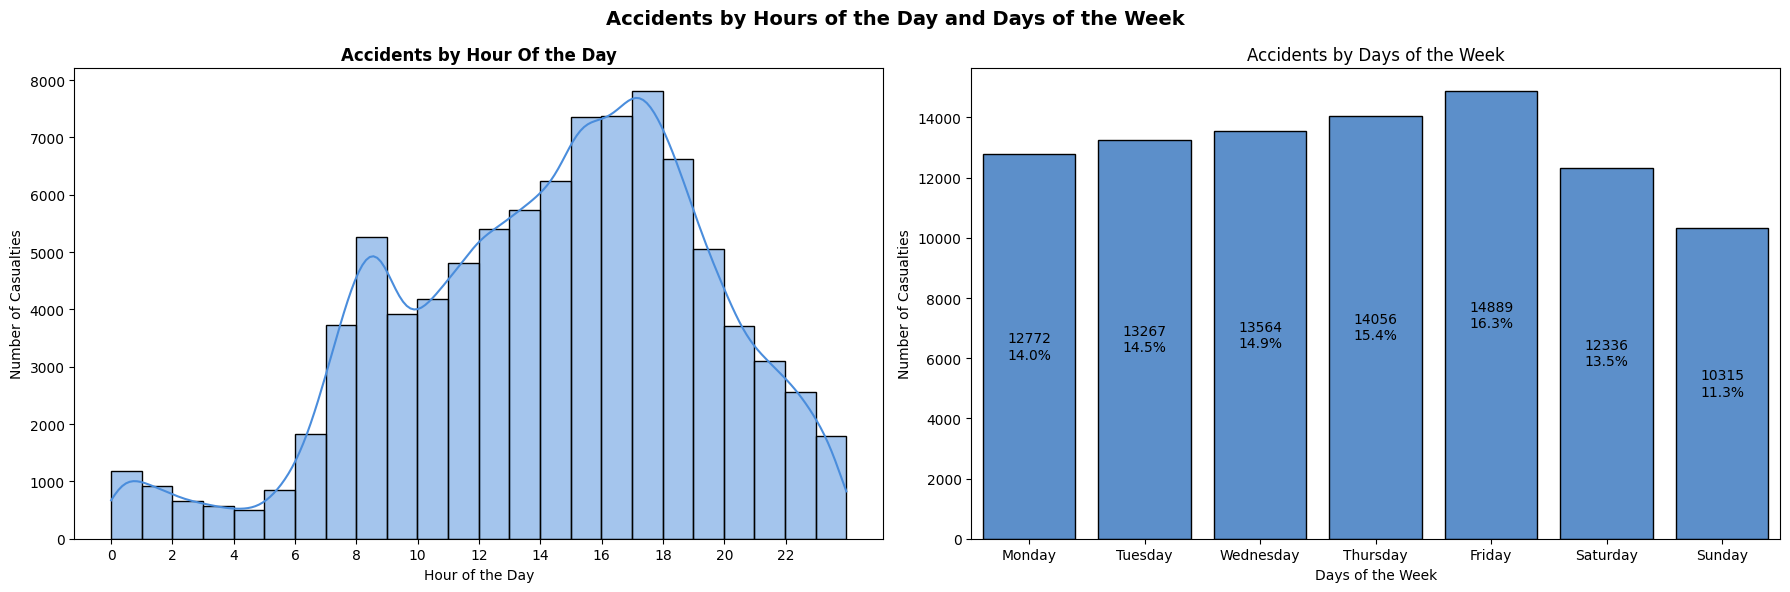

In [45]:
# Create a dictionary that maps weekday codes to their corresponding names
weekday = {
    2: 'Monday',
    3: 'Tuesday',
    4: 'Wednesday',
    5: 'Thursday',
    6: 'Friday',
    7: 'Saturday',
    1: 'Sunday'
}

# Create a figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6), tight_layout=True)

# First plot
sns.histplot(data=accident_df, x='hour_time', bins=24, color="#4A8DDC", edgecolor='black', kde=True, ax=axes[0])
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_title("Accidents by Hour Of the Day", fontweight='bold')
axes[0].set_ylabel('Number of Casualties')
axes[0].set_xlabel("Hour of the Day")

# Create a new column 'weekday' in the 'accident_df' DataFrame by mapping the 'day_of_week' values to their names
accident_df['weekday'] = accident_df['day_of_week'].map(weekday)

# Plot the weekday to show weekdays with most accidents
weekday_plot = sns.countplot(data=accident_df, x="weekday", edgecolor='black', color ="#4A8DDC", order=list(weekday.values()),ax=axes[1])

# Add text labels with the count and percentage of accidents inside each bar in the countplot
#source: https://stackoverflow.com/questions/76240680/how-do-i-add-a-percentage-to-a-countplot
for a in weekday_plot.patches:
    height = a.get_height()
    count = int(height)  # Get the count of accidents in each weekday
    percentage = 100 * height / len(accident_df)
    weekday_plot.text(a.get_x() + a.get_width() / 2., height / 2., f"{count}\n{percentage:.1f}%", ha="center", va="center")

axes[1].set_title("Accidents by Days of the Week")
axes[1].set_ylabel('Number of Casualties')
axes[1].set_xlabel('Days of the Week')
axes[1].tick_params(axis='x')
plt.suptitle("Accidents by Hours of the Day and Days of the Week", fontweight='bold', fontsize = 14)

# Show the combined plot
plt.show()


## No.2
 For motorbikes, are there significant hours of the day, and days of the week, on which accidents occur? We suggest a focus on: Motorcycle 125cc and under, Motorcycle over 125cc and up to 500cc, and Motorcycle over 500cc.


In [46]:
# Store the required vehicle type codes in a list
motorbikes_code = [2,3,4,5]

#assign a variable to the vehicles contained in the vehicle types codes in the list
motorbikes_label = vehicle_df[vehicle_df["vehicle_type"].isin(motorbikes_code)]

motorbikes_label.vehicle_type.unique()

array([3, 2, 4, 5])

In [47]:
#merge accident and vehicle entries that match on accident_index for the required vehicle type
acc_veh_motorbike = pd.merge(accident_df, motorbikes_label, on = "accident_index")
acc_veh_motorbike

,accident_index,accident_year_x,accident_reference_x,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,driver_home_area_type
0,2020010228020,2020,010228020,529718.0,192342.0,-0.127840,51.614971,1,3,2,...,6,1,37,7,114,1,5,YAMAHA XC115,8,1
1,2020010228077,2020,010228077,531477.0,174550.0,-0.109087,51.454673,1,2,2,...,6,1,19,4,-1,-1,-1,-1,5,1
2,2020010228086,2020,010228086,531043.0,176304.0,-0.114680,51.470537,1,3,1,...,6,3,-1,-1,-1,-1,-1,-1,-1,-1
3,2020010228097,2020,010228097,528428.0,179923.0,-0.150994,51.503659,1,3,2,...,6,1,20,4,125,1,4,PEUGEOT TWEET 125,6,1
4,2020010228148,2020,010228148,518467.0,185248.0,-0.292651,51.553691,1,3,1,...,6,1,20,4,125,1,0,HONDA GLR 125,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14121,2020991010130,2020,991010130,250655.0,658068.0,-4.383591,55.792760,99,3,2,...,6,1,47,8,124,1,17,-1,5,1
14122,2020991011809,2020,991011809,268116.0,656638.0,-4.104624,55.785004,99,3,2,...,2,1,61,9,124,1,4,-1,3,1
14123,2020991012311,2020,991012311,311646.0,683727.0,-3.419652,56.038240,99,2,2,...,1,1,35,6,125,1,3,-1,5,1
14124,2020991012353,2020,991012353,318037.0,745230.0,-3.336269,56.591779,99,3,2,...,5,1,48,8,250,1,5,-1,2,1


In [48]:
# Group the data by 'vehicle_type' and calculate the count of each vehicle type
vehicle_type_counts = acc_veh_motorbike['vehicle_type'].value_counts().reset_index()
vehicle_type_counts.columns = ['vehicle_type', 'count']

# Create a DataFrame with the vehicle types and their counts for visualization
vehicle_type_df = motorbikes_label.merge(vehicle_type_counts, on='vehicle_type').drop_duplicates()

# Print the DataFrame containing the mototrcycle vehicle types for visualization
vehicle_type_df

,vehicle_index,accident_index,accident_year,accident_reference,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,driver_home_area_type,count
0,681728,2020010228020,2020,010228020,1,3,0,3,7,3,...,1,37,7,114,1,5,YAMAHA XC115,8,1,7523
1,681749,2020010228086,2020,010228086,1,3,0,18,7,3,...,3,-1,-1,-1,-1,-1,-1,-1,-1,7523
2,681752,2020010228097,2020,010228097,2,3,0,18,1,5,...,1,20,4,125,1,4,PEUGEOT TWEET 125,6,1,7523
3,681774,2020010228148,2020,010228148,1,3,0,14,5,1,...,1,20,4,125,1,0,HONDA GLR 125,2,1,7523
4,681793,2020010228207,2020,010228207,1,3,0,99,9,9,...,1,22,5,125,1,9,HONDA WW125,7,1,7523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14121,848458,2020991003397,2020,991003397,1,5,0,13,8,3,...,1,30,6,599,1,19,-1,6,2,3784
14122,848470,2020991003505,2020,991003505,1,5,0,17,8,4,...,1,53,8,649,1,3,KAWASAKI KLE650,7,1,3784
14123,848551,2020991004857,2020,991004857,2,5,0,18,7,3,...,1,50,8,600,1,20,KAWASAKI MODEL MISSING,1,1,3784
14124,848844,2020991009395,2020,991009395,1,5,0,18,8,4,...,1,48,8,649,1,18,-1,8,1,3784


#### motorbike_50cc_and_under

In [49]:
# Assign a variable to the entries of the respective codes for each vehicle type
motorbike_50cc_and_under = acc_veh_motorbike[acc_veh_motorbike["vehicle_type"] == 2].copy()
motorbike_125cc_and_under = acc_veh_motorbike[acc_veh_motorbike["vehicle_type"] == 3].copy()
motorbike_over_125cc_and_up_to_500cc = acc_veh_motorbike[acc_veh_motorbike["vehicle_type"] == 4].copy()
motorbike_over_500cc = acc_veh_motorbike[acc_veh_motorbike["vehicle_type"] == 5].copy()

In [50]:
motorbike_50cc_and_under['motorbike2_hour'] =  [int(date.split(':')[0]) + (int(date.split(':')[1]) / 60)  for date in motorbike_50cc_and_under['time'] ]


#### motorbike_125cc_and_under

In [51]:
# Add a new column 'motorbike3_hour' to the 'motorbike_125cc_and_under' DataFrame.
# store the hour of the day as a float, where minutes are converted to hour equivalent
motorbike_125cc_and_under['motorbike3_hour'] = [int(date.split(':')[0]) + (int(date.split(':')[1]) / 60) for date in motorbike_125cc_and_under['time']]


### motorbike_over_125cc_and_up_to_500cc

In [52]:
# Add a new column 'motorbike4_hour' to the 'motorbike_over_125cc_and_up_to_500cc' DataFrame.
# store the hour of the day as a float, where minutes are converted to hour equivalent
motorbike_over_125cc_and_up_to_500cc['motorbike4_hour'] = [int(date.split(':')[0]) + (int(date.split(':')[1]) / 60) for date in motorbike_over_125cc_and_up_to_500cc['time']]

### motorbike_over_500cc

In [53]:
# Add a new column 'motorbike5_hour' to the 'motorbike_over_500cc' DataFrame.
# store the hour of the day as a float, where minutes are converted to hour equivalent
motorbike_over_500cc['motorbike5_hour'] = [int(date.split(':')[0]) + (int(date.split(':')[1]) / 60) for date in motorbike_over_500cc['time']]

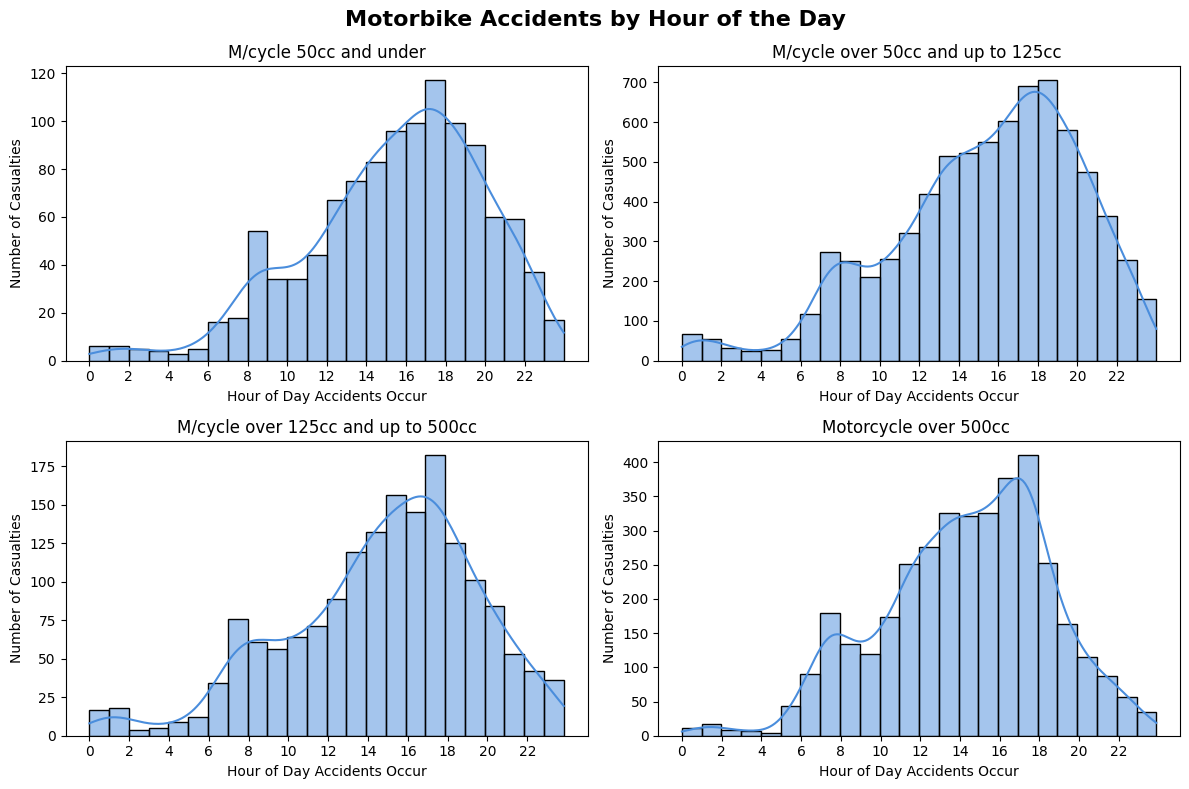

In [54]:
# Create a frame for the different motorbike engine capacity plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot for motorbike_50cc_and_under
sns.histplot(data=motorbike_50cc_and_under, x='motorbike2_hour', bins=24, edgecolor='black', color = "#4A8DDC", kde=True, ax=axes[0, 0])
axes[0, 0].set_title("M/cycle 50cc and under")
axes[0, 0].set_ylabel('Number of Casualties')
axes[0, 0].set_xlabel("Hour of Day Accidents Occur")
axes[0, 0].set_xticks(range(0, 24, 2))

# Plot for motorbike_125cc_and_under
sns.histplot(data=motorbike_125cc_and_under, x="motorbike3_hour", bins=24, edgecolor='black',color = "#4A8DDC", kde=True, ax=axes[0, 1])
axes[0, 1].set_title("M/cycle over 50cc and up to 125cc ")
axes[0, 1].set_ylabel('Number of Casualties')
axes[0, 1].set_xlabel("Hour of Day Accidents Occur")
axes[0, 1].set_xticks(range(0, 24, 2))

# Plot for motorbike_over_125cc_and_up_to_500cc
sns.histplot(data=motorbike_over_125cc_and_up_to_500cc, x="motorbike4_hour", bins=24, edgecolor='black',color = "#4A8DDC", kde=True, ax=axes[1, 0])
axes[1, 0].set_title("M/cycle over 125cc and up to 500cc")
axes[1, 0].set_ylabel('Number of Casualties')
axes[1, 0].set_xlabel("Hour of Day Accidents Occur")
axes[1, 0].set_xticks(range(0, 24, 2))

# Plot for motorbike_over_500cc
sns.histplot(data=motorbike_over_500cc, x="motorbike5_hour", bins=24,color = "#4A8DDC", edgecolor='black', kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Motorcycle over 500cc ")
axes[1, 1].set_ylabel('Number of Casualties')
axes[1, 1].set_xlabel("Hour of Day Accidents Occur")
axes[1, 1].set_xticks(range(0, 24, 2))

#General Title
plt.suptitle('Motorbike Accidents by Hour of the Day', fontsize=16, fontweight='bold')


# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


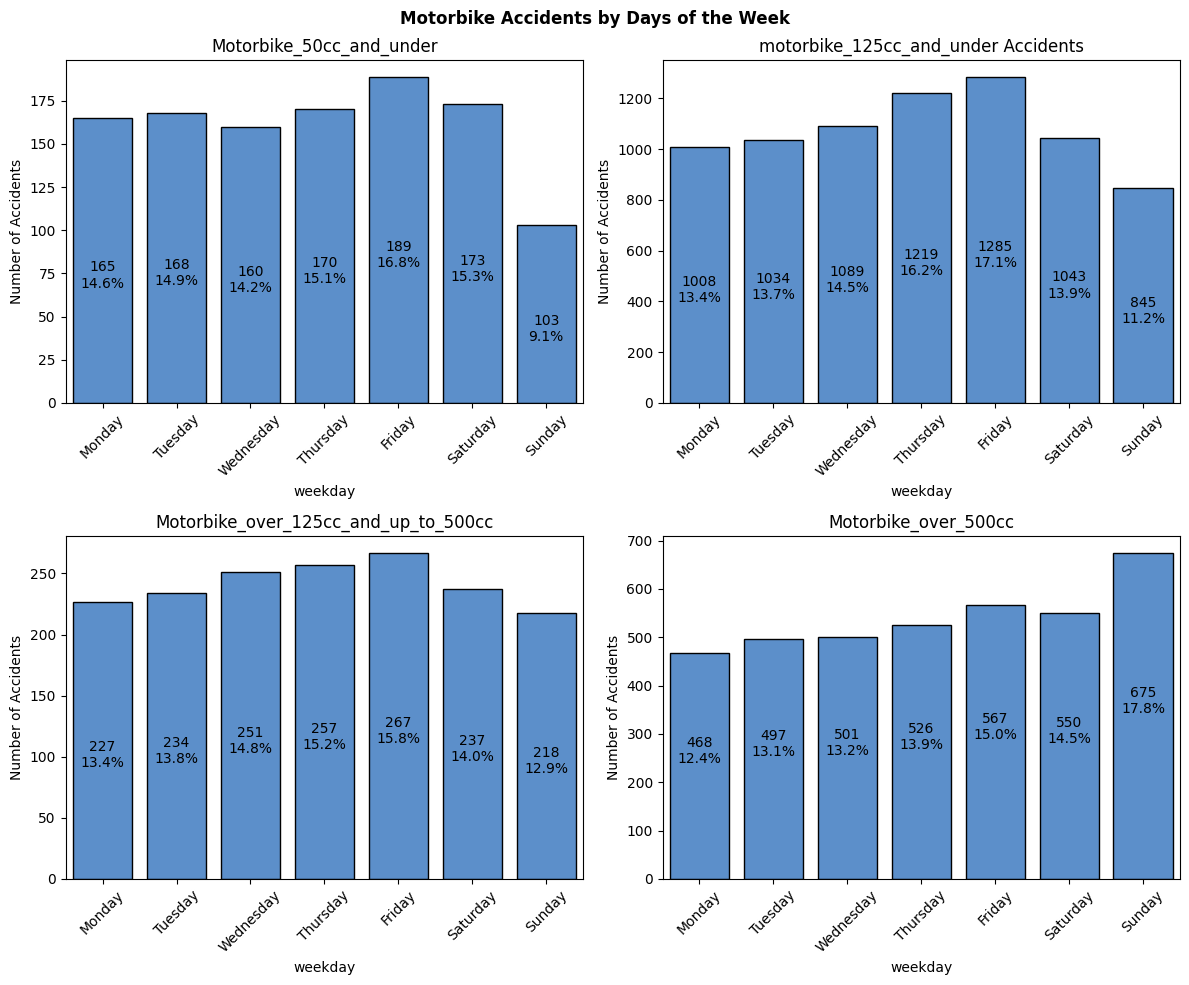

In [55]:
plt.figure(figsize=(12, 10))


# Subplot 1: motorbike_50cc_and_under
plt.subplot(2, 2, 1)
motorbike_50cc_and_under_weekday_plot = sns.countplot(data=motorbike_50cc_and_under, x="weekday", color = "#4A8DDC", edgecolor='black', order=list(weekday.values()))
for a in motorbike_50cc_and_under_weekday_plot.patches:
    height = a.get_height()
    percentage = 100 * height / len(motorbike_50cc_and_under)
    motorbike_50cc_and_under_weekday_plot.text(a.get_x() + a.get_width() / 2., height / 2., f"{int(height)}\n{percentage:.1f}%", ha="center", va="top")
plt.title("Motorbike_50cc_and_under")
plt.ylabel('Number of Accidents')
plt.xticks(rotation = 45)

# Subplot 2: motorbike_125cc_and_under
plt.subplot(2, 2, 2)
motorbike_125cc_and_under_weekday_plot = sns.countplot(data=motorbike_125cc_and_under, x="weekday",color = "#4A8DDC", edgecolor='black', order=list(weekday.values()))
for a in motorbike_125cc_and_under_weekday_plot.patches:
    height = a.get_height()
    percentage = 100 * height / len(motorbike_125cc_and_under)
    motorbike_125cc_and_under_weekday_plot.text(a.get_x() + a.get_width() / 2., height / 2., f"{int(height)}\n{percentage:.1f}%", ha="center", va="top")
plt.title("motorbike_125cc_and_under Accidents")
plt.ylabel('Number of Accidents')
plt.xticks(rotation = 45)

# Subplot 3: motorbike_over_125cc_and_up_to_500cc
plt.subplot(2, 2, 3)
motorbike_over_125cc_and_up_to_500cc_weekday_plot = sns.countplot(data=motorbike_over_125cc_and_up_to_500cc, x="weekday", edgecolor='black', color = "#4A8DDC",order=list(weekday.values()))
for a in motorbike_over_125cc_and_up_to_500cc_weekday_plot.patches:
    height = a.get_height()
    percentage = 100 * height / len(motorbike_over_125cc_and_up_to_500cc)
    motorbike_over_125cc_and_up_to_500cc_weekday_plot.text(a.get_x() + a.get_width() / 2., height / 2., f"{int(height)}\n{percentage:.1f}%", ha="center", va="top")
plt.title("Motorbike_over_125cc_and_up_to_500cc")
plt.ylabel('Number of Accidents')
plt.xticks(rotation = 45)

# Subplot 4: motorbike_over_500cc
plt.subplot(2, 2, 4)
motorbike_over_500cc_weekday_plot = sns.countplot(data=motorbike_over_500cc, x="weekday", edgecolor='black',color = "#4A8DDC", order=list(weekday.values()))
for a in motorbike_over_500cc_weekday_plot.patches:
    height = a.get_height()
    percentage = 100 * height / len(motorbike_over_500cc)
    motorbike_over_500cc_weekday_plot.text(a.get_x() + a.get_width() / 2., height / 2., f"{int(height)}\n{percentage:.1f}%", ha="center", va="bottom")
plt.title("Motorbike_over_500cc")
plt.ylabel('Number of Accidents')
plt.xticks(rotation = 45)

#SET THE SUPER TITLE
plt.suptitle("Motorbike Accidents by Days of the Week", fontweight = "bold")

# Adjust the space between the subplots
plt.tight_layout()

# Show the entire figure
plt.show()


In [56]:
# Define a dictionary with motorbike type full names
motorbike_type_names = {
    '2': 'M/cycle 50cc and under ',
    '3': 'M/cycle over 50cc and up to 125cc',
    '4': 'M/cycle over 125cc and up to 500cc',
    '5': 'Motorcycle over 500cc '
}

# Group by motorbike_type and calculate the sum of number_of_casualties
casualties_by_motorbike_type = acc_veh_motorbike.groupby('vehicle_type')['number_of_casualties'].sum()

# Create a DataFrame from the grouped data
motorbike_casualty_df = pd.DataFrame({
    'Motorbike Type': [motorbike_type_names.get(str(motorbike_type)) for motorbike_type in casualties_by_motorbike_type.index],
    'Number of Casualties': casualties_by_motorbike_type.values
})

# Display the DataFrame
motorbike_casualty_df

,Motorbike Type,Number of Casualties
0,M/cycle 50cc and under,1194
1,M/cycle over 50cc and up to 125cc,8026
2,M/cycle over 125cc and up to 500cc,1863
3,Motorcycle over 500cc,4393


## No. 3

For pedestrians involved in accidents, are there significant hours of the day, and days of the week, on which they are more likely to be involved?

In [57]:
#Assign pedestrians casualty class to a variable
pedestrians=road_accident_df[road_accident_df['casualty_class']== 'Pedestrian']

In [58]:
# Add a new column 'ped_hour' to the 'pedestrians' DataFrame.
# store the hour of the day as a float, where minutes are converted to hour equivalent
pedestrians['ped_hour'] = [int(date.split(':')[0]) + (int(date.split(':')[1]) / 60) for date in pedestrians['time']]

<ipython-input-58-cdb251f406c6>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pedestrians['ped_hour'] = [int(date.split(':')[0]) + (int(date.split(':')[1]) / 60) for date in pedestrians['time']]


<ipython-input-59-e81681d4dfe7>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pedestrians['day_label'] = pedestrians['day_of_week'].map(weekday)


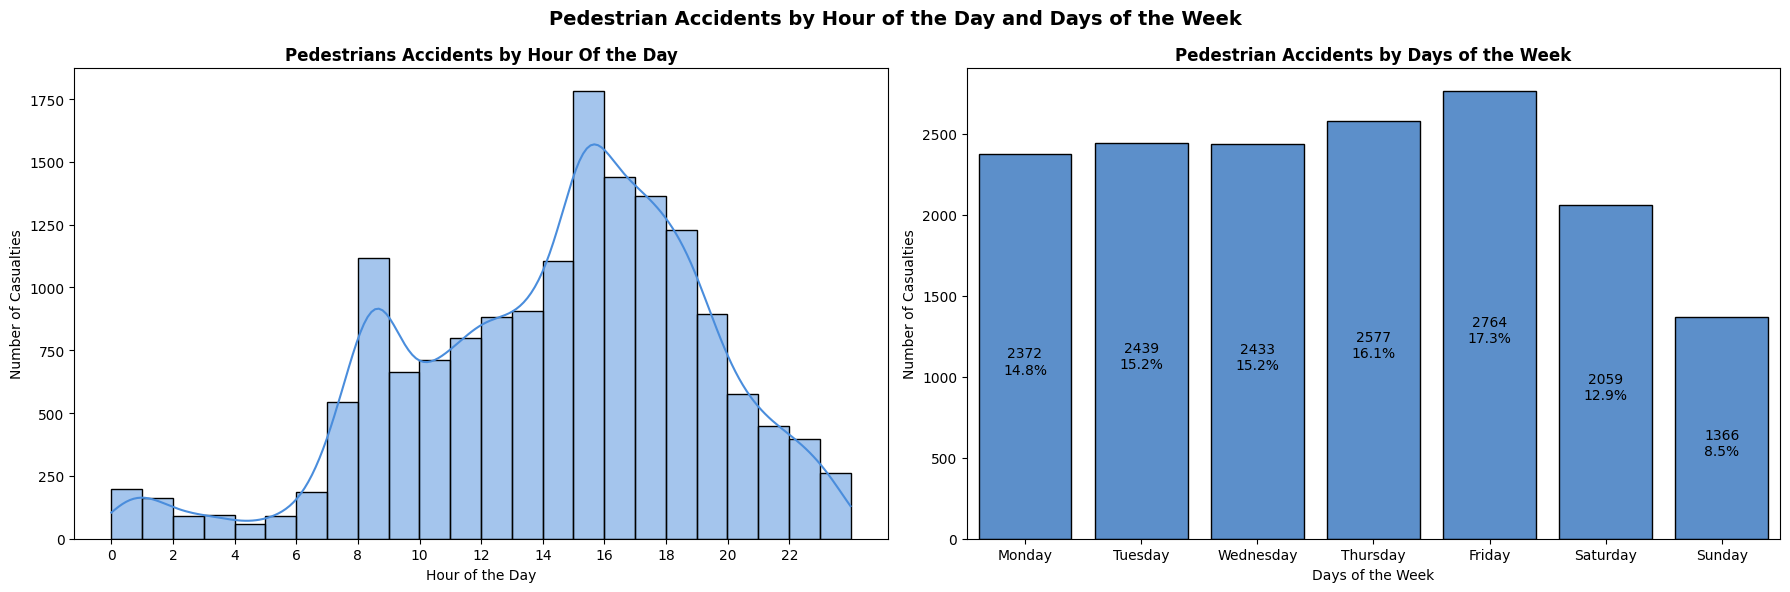

In [59]:
# Create a dictionary that maps weekday codes to their corresponding names
weekday = {
    2: 'Monday',
    3: 'Tuesday',
    4: 'Wednesday',
    5: 'Thursday',
    6: 'Friday',
    7: 'Saturday',
    1: 'Sunday'
}

# Create a figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6), tight_layout=True)

# First plot
sns.histplot(data=pedestrians, x='ped_hour', bins=24, color="#4A8DDC", edgecolor='black', kde=True, ax=axes[0])
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_title("Pedestrians Accidents by Hour Of the Day", fontweight='bold')
axes[0].set_ylabel('Number of Casualties')
axes[0].set_xlabel("Hour of the Day")

# Create a new column 'day_label' in the pedestrians DataFrame by mapping the 'day_of_week' values to their names
pedestrians['day_label'] = pedestrians['day_of_week'].map(weekday)

# Second plot
pedestrians_weekday_plot = sns.countplot(data=pedestrians, x="day_label", edgecolor='black', color="#4A8DDC", order=list(weekday.values()), ax=axes[1])
for a in pedestrians_weekday_plot.patches:
    height = a.get_height()
    percentage = 100 * height / len(pedestrians)
    pedestrians_weekday_plot.text(a.get_x() + a.get_width() / 2., height / 2., f"{int(height)}\n{percentage:.1f}%", ha="center", va="top")
axes[1].set_title("Pedestrian Accidents by Days of the Week", fontweight='bold')
axes[1].set_ylabel('Number of Casualties')
axes[1].set_xlabel('Days of the Week')
axes[1].tick_params(axis='x')
plt.suptitle("Pedestrian Accidents by Hour of the Day and Days of the Week", fontweight = "bold", fontsize = 14)

# Show the combined plot
plt.show()


In [60]:
accident_df['accident_severity'] = accident_df['accident_severity'].map(accident_severity_label)

In [61]:
light_condtions_label = data_label('light_conditions')
light_condtions_label

{1: 'Daylight',
 4: 'Darkness - lights lit',
 5: 'Darkness - lights unlit',
 6: 'Darkness - no lighting',
 7: 'Darkness - lighting unknown',
 -1: 'Data missing or out of range'}

In [62]:
weather_conditions_label

{1: 'Fine no high winds',
 2: 'Raining no high winds',
 3: 'Snowing no high winds',
 4: 'Fine + high winds',
 5: 'Raining + high winds',
 6: 'Snowing + high winds',
 7: 'Fog or mist',
 8: 'Other',
 9: 'Unknown',
 -1: 'Data missing or out of range'}

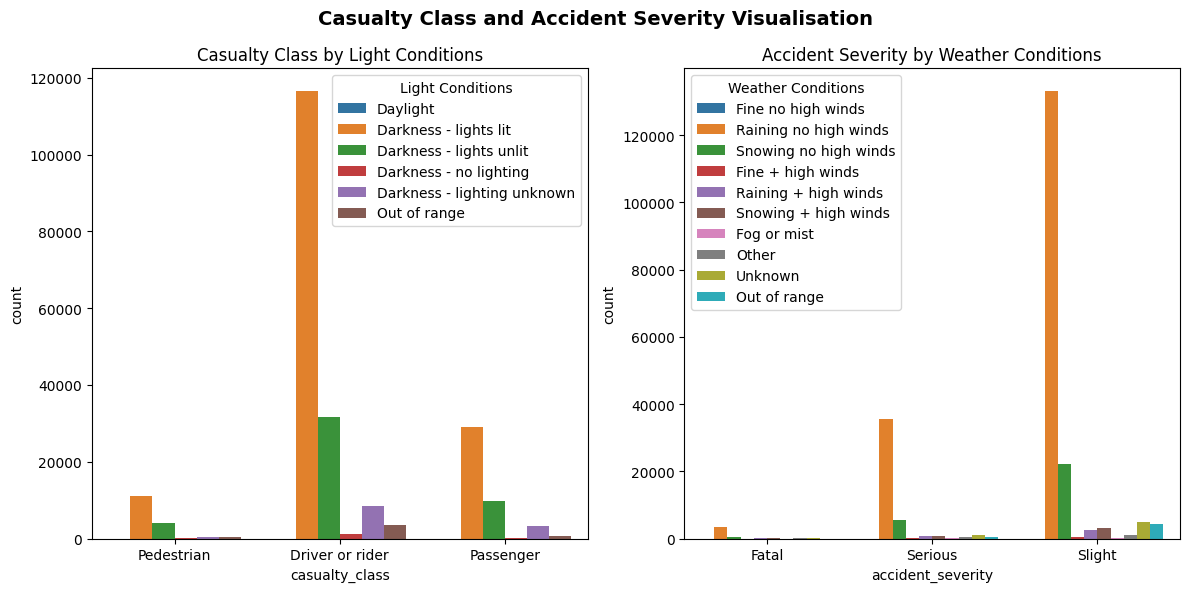

In [63]:
fig, ([ax1, ax2]) = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)
plt.suptitle("Casualty Class and Accident Severity Visualisation", fontsize =14, fontweight = "bold")
sns.countplot(data=road_accident_df, hue='light_conditions', x='casualty_class', ax=ax1).set(title="Casualty Class by Light Conditions")
ax1.legend(title='Light Conditions', labels=['Daylight', 'Darkness - lights lit', 'Darkness - lights unlit', 'Darkness - no lighting', 'Darkness - lighting unknown', 'Out of range'])

sns.countplot(data=road_accident_df, hue='weather_conditions', x='accident_severity', ax=ax2).set(title="Accident Severity by Weather Conditions")
ax2.legend(title='Weather Conditions', labels=['Fine no high winds', 'Raining no high winds', 'Snowing no high winds', 'Fine + high winds', 'Raining + high winds', 'Snowing + high winds', 'Fog or mist', 'Other', 'Unknown', 'Out of range'])
ax2.set_xticklabels(['Fatal', 'Serious', 'Slight'])  # Set  x-axis tick labels

plt.show()

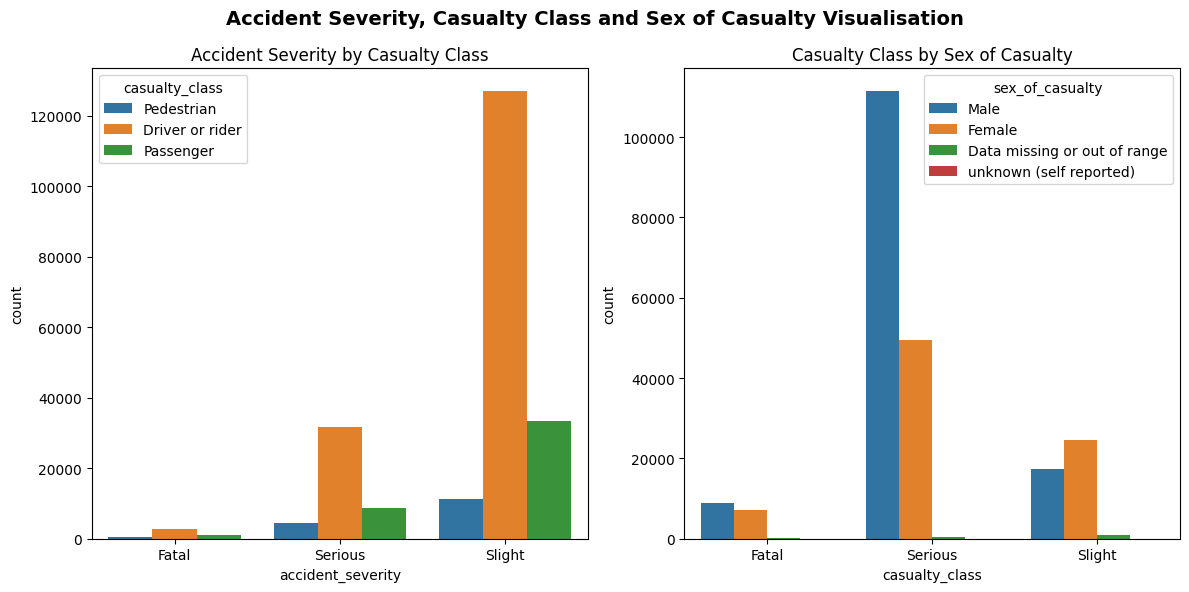

In [64]:
#set the axes for the subplots
fig, ([ax1, ax2]) = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)

plt.suptitle("Accident Severity, Casualty Class and Sex of Casualty Visualisation", fontsize =14, fontweight = "bold")


#make a plot of accident severity by casualty class
sns.countplot(data=road_accident_df, x='accident_severity', hue='casualty_class', ax=ax1).set(title="Accident Severity by Casualty Class")
ax1.set_xticklabels(['Fatal', 'Serious', 'Slight'])  # Set  x-axis tick labels

#Plot of Casualty class by gender
sns.countplot(data=road_accident_df, x='casualty_class', hue='sex_of_casualty', ax=ax2).set(title="Casualty Class by Sex of Casualty")
ax2.set_xticklabels(['Fatal', 'Serious', 'Slight'])  # Set  x-axis tick labels

plt.show()


In [65]:
pedestrian_crossing_physical_facilities_label = data_label("pedestrian_crossing_physical_facilities")
pedestrian_crossing_physical_facilities_label

{0: 'No physical crossing facilities within 50 metres',
 1: 'Zebra',
 4: 'Pelican, puffin, toucan or similar non-junction pedestrian light crossing',
 5: 'Pedestrian phase at traffic signal junction',
 7: 'Footbridge or subway',
 8: 'Central refuge',
 -1: 'Data missing or out of range',
 9: 'unknown (self reported)'}

In [66]:
pedestrian_crossing_human_control_label = data_label("pedestrian_crossing_human_control")
pedestrian_crossing_human_control_label

{0: 'None within 50 metres ',
 1: 'Control by school crossing patrol',
 2: 'Control by other authorised person',
 -1: 'Data missing or out of range',
 9: 'unknown (self reported)'}

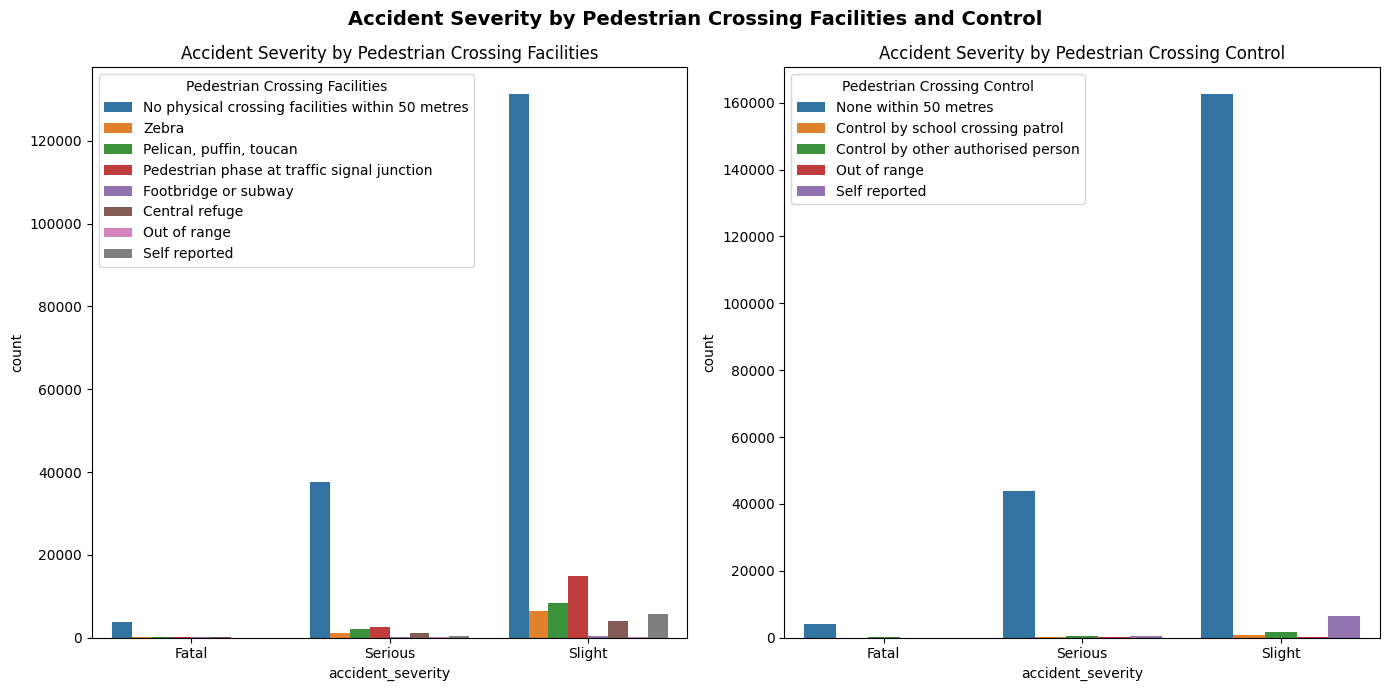

In [67]:
# Set the axes for the subplots
fig, ([ax1, ax2]) = plt.subplots(1, 2, figsize=(14, 7), tight_layout=True)

plt.suptitle("Accident Severity by Pedestrian Crossing Facilities and Control", fontsize=14, fontweight="bold")

# Define the legend labels and order for pedestrian_crossing_physical_facilities
crossing_physical_legend_labels = {
    0: 'No physical crossing facilities within 50 metres',
    1: 'Zebra',
    4: 'Pelican, puffin, toucan',
    5: 'Pedestrian phase at traffic signal junction',
    7: 'Footbridge or subway',
    8: 'Central refuge',
    -1: 'Out of range',
    9: 'Self reported'
}

crossing_physical_order = list(crossing_physical_legend_labels.keys())

# Make a plot of accident severity by pedestrian_crossing_physical_facilities
sns.countplot(data=road_accident_df, x='accident_severity', hue='pedestrian_crossing_physical_facilities', hue_order=crossing_physical_order, ax=ax1).set(title="Accident Severity by Pedestrian Crossing Facilities")
ax1.set_xticklabels(['Fatal', 'Serious', 'Slight'])  # Set x-axis tick labels
ax1.legend(title='Pedestrian Crossing Facilities', labels=crossing_physical_legend_labels.values())

# Define the legend labels and order for pedestrian_crossing_human_control
crossing_human_legend_labels = {
    0: 'None within 50 metres',
    1: 'Control by school crossing patrol',
    2: 'Control by other authorised person',
    -1: 'Out of range',
    9: 'Self reported'
}

crossing_human_order = list(crossing_human_legend_labels.keys())

# Plot of accident severity by pedestrian_crossing_human_control
sns.countplot(data=road_accident_df, x='accident_severity', hue='pedestrian_crossing_human_control', hue_order=crossing_human_order, ax=ax2).set(title="Accident Severity by Pedestrian Crossing Control")
ax2.set_xticklabels(['Fatal', 'Serious', 'Slight'])  # Set x-axis tick labels
ax2.legend(title='Pedestrian Crossing Control', labels=crossing_human_legend_labels.values())

plt.show()


## No.4
Using the apriori algorithm, explore the impact of selected variables on accident severity.

## Feature selection for the Apriori algorithm for the individual tables

In [68]:
accident_df.corr()

,accident_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,number_of_vehicles,number_of_casualties,day_of_week,local_authority_district,...,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,hour_time
accident_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_easting_osgr,NaN,1.000000,-0.408338,0.999464,-0.410957,-0.356411,0.036464,-0.037599,0.000674,-0.380097,...,0.139952,0.012329,0.019502,0.014192,0.083566,0.079518,-0.121276,0.146753,0.480538,0.002124
location_northing_osgr,NaN,-0.408338,1.000000,-0.415644,0.999969,0.133548,-0.037935,0.036254,0.000610,0.094089,...,-0.091346,-0.009247,-0.007987,-0.020885,-0.069364,-0.063667,0.051715,-0.044148,-0.416588,0.003570
longitude,NaN,0.999464,-0.415644,1.000000,-0.418186,-0.366395,0.036879,-0.036937,0.000330,-0.387232,...,0.137557,0.011884,0.018708,0.012924,0.082582,0.078168,-0.118561,0.144446,0.494800,0.001781
latitude,NaN,-0.410957,0.999969,-0.418186,1.000000,0.131907,-0.037823,0.036271,0.000594,0.093051,...,-0.091401,-0.009270,-0.008158,-0.021026,-0.069595,-0.063955,0.051180,-0.044686,-0.414992,0.003572
police_force,NaN,-0.356411,0.133548,-0.366395,0.131907,1.000000,-0.024486,0.045952,-0.001153,0.957204,...,-0.217406,-0.002007,-0.029516,-0.037070,-0.112746,-0.097261,0.289132,-0.185557,-0.636193,-0.024244
number_of_vehicles,NaN,0.036464,-0.037935,0.036879,-0.037823,-0.024486,1.000000,0.197352,0.001049,-0.021549,...,-0.028311,-0.066207,-0.039710,-0.042714,-0.021246,-0.032385,-0.003960,-0.011834,0.016552,0.011221
number_of_casualties,NaN,-0.037599,0.036254,-0.036937,0.036271,0.045952,0.197352,1.000000,0.001622,0.052165,...,-0.052711,0.028582,-0.016323,0.002003,-0.025565,-0.027132,0.117632,-0.106105,-0.035720,0.019138
day_of_week,NaN,0.000674,0.000610,0.000330,0.000594,-0.001153,0.001049,0.001622,1.000000,-0.000966,...,0.002087,0.019993,-0.000086,0.004076,-0.000491,-0.000153,-0.015424,0.003951,0.001248,0.037340
local_authority_district,NaN,-0.380097,0.094089,-0.387232,0.093051,0.957204,-0.021549,0.052165,-0.000966,1.000000,...,-0.234195,-0.004804,-0.037608,-0.045376,-0.121900,-0.107003,0.300031,-0.203915,-0.563401,-0.025099


In [69]:
#select possible columns that might affect accident severity
accident_ap_columns= ["accident_index","weather_conditions", "accident_severity", "road_type", "speed_limit", "lsoa_of_accident_location", "police_force", 'light_conditions', "urban_or_rural_area"]
vehicle_ap_columns = ["accident_index", "vehicle_type","vehicle_manoeuvre", "sex_of_driver", "first_point_of_impact", "engine_capacity_cc"]
casualty_ap_columns = ["accident_index", "casualty_class", "pedestrian_location", "sex_of_casualty", "bus_or_coach_passenger","car_passenger", "casualty_type" ]

In [70]:
# Reverse the 'accident_severity_label' dictionary to map labels back to numerical values
reverse_accident_severity = {v: k for k, v in accident_severity_label.items()}

# Map the labels back to numerical values in the 'accident_severity' column
accident_df['accident_severity'] = accident_df['accident_severity'].map(reverse_accident_severity)


accident_apriori_df= accident_df[accident_ap_columns]
vehicle_apriori_df = vehicle_df[vehicle_ap_columns]
casualty_apriori_df = casualty_df[casualty_ap_columns]

In [71]:
# Merge the dataframes
acc_veh_ap_df = accident_apriori_df.merge(vehicle_apriori_df, on = "accident_index")

#merge with casualty apriori features to get the combined df
apriori_df = acc_veh_ap_df.merge(casualty_apriori_df, on = "accident_index")
apriori_df

,accident_index,weather_conditions,accident_severity,road_type,speed_limit,lsoa_of_accident_location,police_force,light_conditions,urban_or_rural_area,vehicle_type,vehicle_manoeuvre,sex_of_driver,first_point_of_impact,engine_capacity_cc,casualty_class,pedestrian_location,sex_of_casualty,bus_or_coach_passenger,car_passenger,casualty_type
0,2020010219808,9,3,6,20,E01004576,1,1,1,9,5,2,4,1968,3,9,1,0,0,0
1,2020010220496,1,3,6,20,E01003034,1,1,1,9,4,1,1,1395,3,1,2,0,0,0
2,2020010220496,1,3,6,20,E01003034,1,1,1,9,4,1,1,1395,3,1,2,0,0,0
3,2020010228005,1,3,6,30,E01004726,1,4,1,9,18,3,1,-1,3,5,1,0,0,0
4,2020010228006,1,2,6,30,E01003617,1,4,1,8,18,1,1,1798,3,4,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220430,2020991030297,1,2,6,60,-1,99,1,2,9,7,1,3,1968,1,0,1,0,0,5
220431,2020991030297,1,2,6,60,-1,99,1,2,5,16,1,1,1301,1,0,1,0,0,5
220432,2020991030900,1,3,6,30,-1,99,1,1,9,7,2,3,1995,1,0,1,0,0,1
220433,2020991030900,1,3,6,30,-1,99,1,1,1,18,1,1,-1,1,0,1,0,0,1


In [72]:
'''apriori_df_onehot = pd.get_dummies(apriori_df, columns= apriori_df.columns)
apriori_df_onehot'''#consumed all RAM

'apriori_df_onehot = pd.get_dummies(apriori_df, columns= apriori_df.columns)\napriori_df_onehot'

In [73]:
# Select the important features and define the target
features = apriori_df.drop(["accident_index", "speed_limit", "engine_capacity_cc", "lsoa_of_accident_location"], axis =1)
features.head()

,weather_conditions,accident_severity,road_type,police_force,light_conditions,urban_or_rural_area,vehicle_type,vehicle_manoeuvre,sex_of_driver,first_point_of_impact,casualty_class,pedestrian_location,sex_of_casualty,bus_or_coach_passenger,car_passenger,casualty_type
0,9,3,6,1,1,1,9,5,2,4,3,9,1,0,0,0
1,1,3,6,1,1,1,9,4,1,1,3,1,2,0,0,0
2,1,3,6,1,1,1,9,4,1,1,3,1,2,0,0,0
3,1,3,6,1,4,1,9,18,3,1,3,5,1,0,0,0
4,1,2,6,1,4,1,8,18,1,1,3,4,1,0,0,0


In [74]:
#Define function to encode data for apriori.
#Source = https://stackoverflow.com/questions/62270442/how-to-convert-a-dataframe-into-the-dataframe-for-apriori-algorithm
def one_hot(x):
  if x <= 1:
    return 0
  else:
    return 1

In [75]:
encoded_features = features.applymap(one_hot)
encoded_features

,weather_conditions,accident_severity,road_type,police_force,light_conditions,urban_or_rural_area,vehicle_type,vehicle_manoeuvre,sex_of_driver,first_point_of_impact,casualty_class,pedestrian_location,sex_of_casualty,bus_or_coach_passenger,car_passenger,casualty_type
0,1,1,1,0,0,0,1,1,1,1,1,1,0,0,0,0
1,0,1,1,0,0,0,1,1,0,0,1,0,1,0,0,0
2,0,1,1,0,0,0,1,1,0,0,1,0,1,0,0,0
3,0,1,1,0,1,0,1,1,1,0,1,1,0,0,0,0
4,0,1,1,0,1,0,1,1,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220430,0,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1
220431,0,1,1,1,0,1,1,1,0,0,0,0,0,0,0,1
220432,0,1,1,1,0,0,1,1,1,1,0,0,0,0,0,0
220433,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0


## Apriori

In [76]:
apriori_onehot = pd.get_dummies(features, columns = features.columns)
apriori_onehot

,weather_conditions_-1,weather_conditions_1,weather_conditions_2,weather_conditions_3,weather_conditions_4,weather_conditions_5,weather_conditions_6,weather_conditions_7,weather_conditions_8,weather_conditions_9,...,casualty_type_17,casualty_type_18,casualty_type_19,casualty_type_20,casualty_type_21,casualty_type_22,casualty_type_23,casualty_type_90,casualty_type_97,casualty_type_98
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220430,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
220431,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
220432,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
220433,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [77]:
weather_conditions_label

{1: 'Fine no high winds',
 2: 'Raining no high winds',
 3: 'Snowing no high winds',
 4: 'Fine + high winds',
 5: 'Raining + high winds',
 6: 'Snowing + high winds',
 7: 'Fog or mist',
 8: 'Other',
 9: 'Unknown',
 -1: 'Data missing or out of range'}

### Support

In [78]:
support_accident = apriori(apriori_onehot, min_support= 0.5, use_colnames= True)
support_accident.head(30)

,support,itemsets
0,0.780888,(weather_conditions_1)
1,0.777445,(accident_severity_3)
2,0.720652,(road_type_6)
3,0.710599,(light_conditions_1)
4,0.642634,(urban_or_rural_area_1)
5,0.718266,(vehicle_type_9)
6,0.638175,(sex_of_driver_1)
7,0.502611,(first_point_of_impact_1)
8,0.732325,(casualty_class_1)
9,0.927371,(pedestrian_location_0)


### Association rules

In [79]:
#assign the association rules for confidence
confidence_rule = association_rules(support_accident, metric="confidence", min_threshold=0.7)
print("The Confidence DataFrame is as follows:")
confidence_rule

The Confidence DataFrame is as follows:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(weather_conditions_1),(accident_severity_3),0.780888,0.777445,0.604246,0.773794,0.995304,-0.002851,0.983861,-0.021079
1,(accident_severity_3),(weather_conditions_1),0.777445,0.780888,0.604246,0.777221,0.995304,-0.002851,0.983540,-0.020759
2,(weather_conditions_1),(road_type_6),0.780888,0.720652,0.570037,0.729985,1.012951,0.007288,1.034564,0.058349
3,(road_type_6),(weather_conditions_1),0.720652,0.780888,0.570037,0.791001,1.012951,0.007288,1.048387,0.045767
4,(light_conditions_1),(weather_conditions_1),0.710599,0.780888,0.584236,0.822173,1.052870,0.029337,1.232165,0.173513
...,...,...,...,...,...,...,...,...,...,...
802,"(sex_of_casualty_1, car_passenger_0)","(pedestrian_location_0, bus_or_coach_passenger...",0.556717,0.732325,0.506131,0.909135,1.241436,0.098433,2.945844,0.438730
803,"(bus_or_coach_passenger_0, sex_of_casualty_1)","(pedestrian_location_0, car_passenger_0, casua...",0.622805,0.732325,0.506131,0.812664,1.109704,0.050036,1.428850,0.262090
804,"(pedestrian_location_0, sex_of_casualty_1)","(casualty_class_1, bus_or_coach_passenger_0, c...",0.585030,0.732325,0.506131,0.865138,1.181358,0.077699,1.984802,0.369945
805,"(casualty_class_1, sex_of_casualty_1)","(pedestrian_location_0, bus_or_coach_passenger...",0.506131,0.743925,0.506131,1.000000,1.344222,0.129608,inf,0.518509


In [80]:
#assign the association rule for lift
lift_rule = association_rules(support_accident, metric = "lift", min_threshold = 0.7)
print("The Lift DataFrame is as follows:")
lift_rule

The Lift DataFrame is as follows:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(weather_conditions_1),(accident_severity_3),0.780888,0.777445,0.604246,0.773794,0.995304,-0.002851,0.983861,-0.021079
1,(accident_severity_3),(weather_conditions_1),0.777445,0.780888,0.604246,0.777221,0.995304,-0.002851,0.983540,-0.020759
2,(weather_conditions_1),(road_type_6),0.780888,0.720652,0.570037,0.729985,1.012951,0.007288,1.034564,0.058349
3,(road_type_6),(weather_conditions_1),0.720652,0.780888,0.570037,0.791001,1.012951,0.007288,1.048387,0.045767
4,(light_conditions_1),(weather_conditions_1),0.710599,0.780888,0.584236,0.822173,1.052870,0.029337,1.232165,0.173513
...,...,...,...,...,...,...,...,...,...,...
1125,(car_passenger_0),"(pedestrian_location_0, bus_or_coach_passenger...",0.825246,0.506131,0.506131,0.613310,1.211761,0.088449,1.277169,1.000000
1126,(bus_or_coach_passenger_0),"(pedestrian_location_0, sex_of_casualty_1, car...",0.991190,0.506131,0.506131,0.510630,1.008888,0.004459,1.009193,1.000000
1127,(pedestrian_location_0),"(casualty_class_1, bus_or_coach_passenger_0, c...",0.927371,0.506131,0.506131,0.545770,1.078317,0.036760,1.087266,1.000000
1128,(sex_of_casualty_1),"(pedestrian_location_0, bus_or_coach_passenger...",0.625663,0.732325,0.506131,0.808952,1.104635,0.047943,1.401087,0.253044


In [81]:
#assign the association rule for conviction
conviction_rule = association_rules(support_accident, metric = "conviction", min_threshold = 0.7)
print("The Conviction DataFrame is as follows:")
conviction_rule

The Conviction DataFrame is as follows:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(weather_conditions_1),(accident_severity_3),0.780888,0.777445,0.604246,0.773794,0.995304,-0.002851,0.983861,-0.021079
1,(accident_severity_3),(weather_conditions_1),0.777445,0.780888,0.604246,0.777221,0.995304,-0.002851,0.983540,-0.020759
2,(weather_conditions_1),(road_type_6),0.780888,0.720652,0.570037,0.729985,1.012951,0.007288,1.034564,0.058349
3,(road_type_6),(weather_conditions_1),0.720652,0.780888,0.570037,0.791001,1.012951,0.007288,1.048387,0.045767
4,(light_conditions_1),(weather_conditions_1),0.710599,0.780888,0.584236,0.822173,1.052870,0.029337,1.232165,0.173513
...,...,...,...,...,...,...,...,...,...,...
1122,(car_passenger_0),"(pedestrian_location_0, bus_or_coach_passenger...",0.825246,0.506131,0.506131,0.613310,1.211761,0.088449,1.277169,1.000000
1123,(bus_or_coach_passenger_0),"(pedestrian_location_0, sex_of_casualty_1, car...",0.991190,0.506131,0.506131,0.510630,1.008888,0.004459,1.009193,1.000000
1124,(pedestrian_location_0),"(casualty_class_1, bus_or_coach_passenger_0, c...",0.927371,0.506131,0.506131,0.545770,1.078317,0.036760,1.087266,1.000000
1125,(sex_of_casualty_1),"(pedestrian_location_0, bus_or_coach_passenger...",0.625663,0.732325,0.506131,0.808952,1.104635,0.047943,1.401087,0.253044


# No.5
Identify accidents in our region: Kingston upon Hull, Humberside, and the East Riding of Yorkshire etc. You can do this by filtering on LSOA, or police region or another method if you can find one. Run clustering on this data. What do these clusters reveal about the distribution of accidents in our region?

## Feature selection for KMeans


In [82]:
#Extract data for Humberside via the National Police Force PNC code 16
# source = https://en.wikipedia.org/wiki/Aerial_roof_markings#Unique_PNC_force_code and STAT20 form
humberside_PNC_code = accident_df[accident_df['police_force']== 16]

In [83]:
#create a new df to contain columns of interest from the accident df
geo_cord = accident_df[['longitude', 'latitude']]
geo_cord

,longitude,latitude
0,-0.254001,51.462262
1,-0.139253,51.470327
2,-0.178719,51.529614
3,-0.001683,51.541210
4,-0.137592,51.515704
...,...,...
91194,-2.926320,56.473539
91195,-4.267565,55.802353
91196,-2.271903,57.186317
91197,-3.968753,55.950940


In [84]:
#Missing coordinates
missing_rows = geo_cord[geo_cord.isna().any(axis=1)]

print("Rows with coordinates:")
missing_rows


Rows with coordinates:


,longitude,latitude
25520,NaN,NaN
29452,NaN,NaN
32689,NaN,NaN
33578,NaN,NaN
81252,NaN,NaN
86437,NaN,NaN
86642,NaN,NaN
86651,NaN,NaN
86668,NaN,NaN
86705,NaN,NaN


In [85]:
#Initiate KNNImputer
imputer = KNNImputer(n_neighbors=5)

# Perform imputation
geo_cord_imputed = imputer.fit_transform(geo_cord)

# Convert the imputed array back to a DataFrame
geo_cord_imputed_df = pd.DataFrame(geo_cord_imputed, columns=geo_cord.columns)

# Replace the values in the original geo_cord DataFrame with the imputed values
geo_cord[geo_cord.columns] = geo_cord_imputed_df[geo_cord.columns]

# Check for null values in the updated geo_cord DataFrame
print(geo_cord.isnull().sum())



longitude    0
latitude     0
dtype: int64


<ipython-input-85-41f490afe21d>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  geo_cord[geo_cord.columns] = geo_cord_imputed_df[geo_cord.columns]


In [86]:
humberside_geo_cord = humberside_PNC_code[['longitude', 'latitude']]
humberside_geo_cord

,longitude,latitude
37750,-0.331047,53.747751
37751,-0.393424,53.744936
37752,-0.528743,53.512895
37753,-0.324858,53.791630
37754,-0.095008,53.574501
...,...,...
39454,-0.651104,53.566753
39455,-0.424674,53.839482
39456,-0.308880,53.782750
39457,-0.703181,53.569801


In [87]:
#Data normalisation
scaler = StandardScaler()
geo_cord_scaled = scaler.fit_transform(geo_cord)
humberside_geo_cord_scaled =  scaler.fit_transform(humberside_geo_cord)

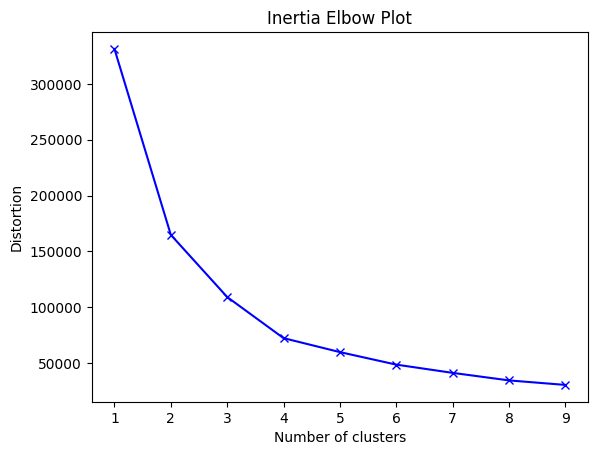

In [88]:
distortions = []
K = range(1, 10)
for k in K:
    kmeans= KMeans(n_clusters=k, random_state=42)
    kmeans.fit(geo_cord)
    distortions.append((kmeans.inertia_))

plt.plot(K, distortions, "bx-")
plt.xlabel("Number of clusters")
plt.ylabel("Distortion")
plt.title("Inertia Elbow Plot")
plt.show()

Relationship between Inertia and number of clusters: As the number of clusters increase, the inertia decreases

In [89]:
kmeans = KMeans(n_clusters = 5, random_state = 42)
kmeans.fit(geo_cord)

KMeans(n_clusters=5, random_state=42)

In [90]:
kmeans.fit(humberside_geo_cord)

KMeans(n_clusters=5, random_state=42)

In [91]:
humber_labels = kmeans.predict(humberside_geo_cord)
humber_labels

array([0, 0, 4, ..., 0, 4, 0], dtype=int32)

In [92]:
centroids = kmeans.cluster_centers_
centroid_points = len(centroids)
uk_labels = kmeans.predict(geo_cord)
uk_labels

array([1, 1, 1, ..., 2, 2, 2], dtype=int32)

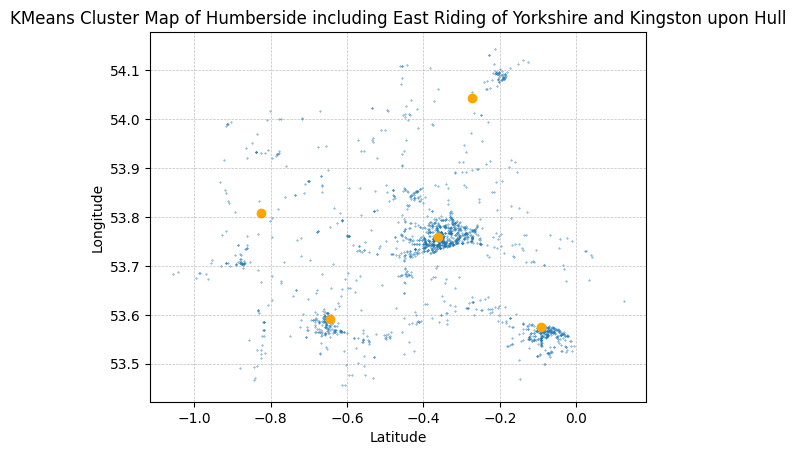

In [93]:
fig, axes = plt.subplots()
axes.scatter(humberside_geo_cord['longitude'],humberside_geo_cord['latitude'],s=0.1)
plt.scatter(centroids[:, 0], centroids[:, 1], color = 'orange')

# Add a faint grid
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)


plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('KMeans Cluster Map of Humberside including East Riding of Yorkshire and Kingston upon Hull')
plt.show()

In [94]:
'''uk_labels = kmeans.predict(geo_cord)
centroids = kmeans.cluster_centers_
centroid_points = len(centroids)'''

'uk_labels = kmeans.predict(geo_cord)\ncentroids = kmeans.cluster_centers_\ncentroid_points = len(centroids)'

In [95]:
humberside_geo_cord['clusters'] = humber_labels
geo_cord['clusters'] = uk_labels

<ipython-input-95-d28de6dcd309>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  humberside_geo_cord['clusters'] = humber_labels
<ipython-input-95-d28de6dcd309>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  geo_cord['clusters'] = uk_labels


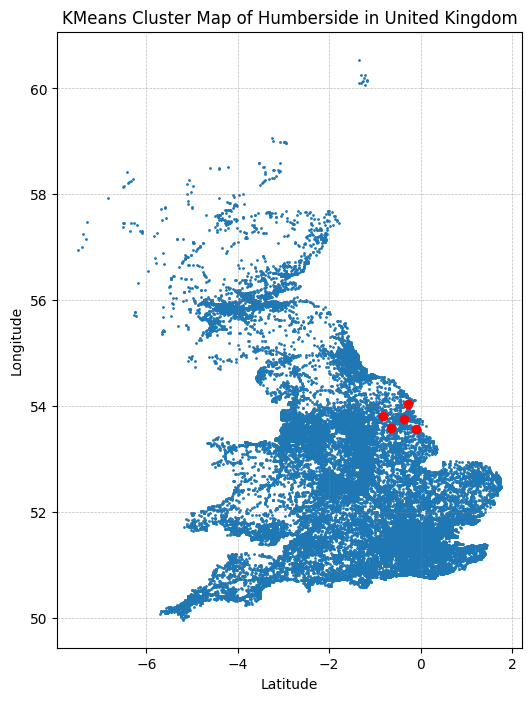

In [96]:
#plotting the attributes to see how they affect the clusters formed
fig= plt.figure(figsize= (6,8))
plt.scatter (geo_cord["longitude"], geo_cord["latitude"], s=1)

plt.scatter(centroids[:,0], centroids[:,1], color = "red")

# Add a faint grid
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('KMeans Cluster Map of Humberside in United Kingdom')
plt.show()

In [97]:
geo_cord.clusters.unique()

array([1, 4, 2, 3, 0], dtype=int32)

## Geographic clustering: DBSCAN

In [98]:
# Assign the needed columns to the variable X for easy reconciliation with workshop codes
X = geo_cord

In [99]:
from numpy.random import default_rng

rng = default_rng()
idx = rng.choice(X.shape[0], size=20000, replace=False)
X_small = X.iloc[idx]

In [100]:
dbscan_opt = DBSCAN(eps=31,min_samples=6)
dbscan_opt.fit(X_small)
labels = dbscan_opt.labels_
labels

array([0, 0, 0, ..., 0, 0, 0])

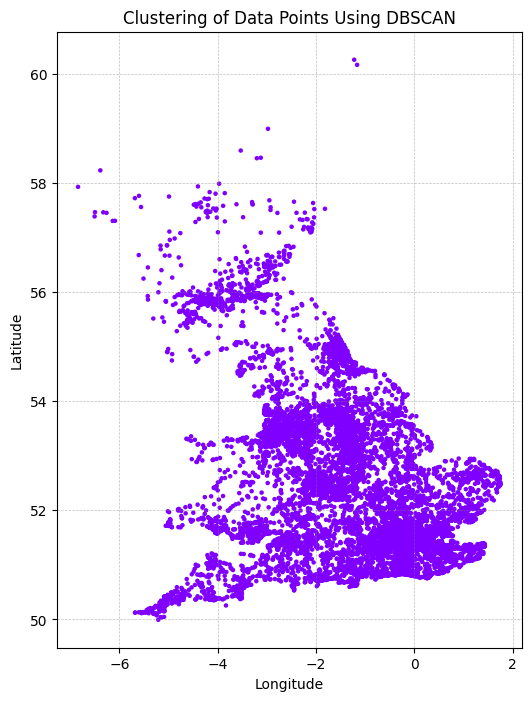

In [101]:
# Set the figure size
plt.figure(figsize=(6, 8))

# Scatter plot of data points colored by cluster labels
plt.scatter(X_small['longitude'], X_small['latitude'], c=labels, s=5, cmap='rainbow')

# Add a title to the plot
plt.title('Clustering of Data Points Using DBSCAN')

# Add a faint grid
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Add labels to the x and y axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show the plot
plt.show()

In [102]:
dbscan_opt = DBSCAN(eps=0.1,min_samples=10)
dbscan_opt.fit(X_small)
labels = dbscan_opt.labels_
labels

array([0, 1, 2, ..., 2, 1, 0])

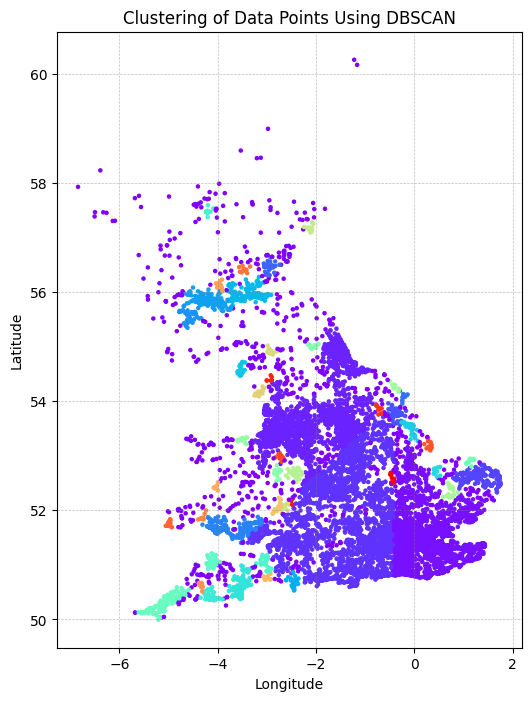

In [103]:
'''plt.figure(figsize=(6,8))
plt.scatter(X_small['longitude'], X_small['latitude'], c=labels, s=40, cmap='rainbow')
plt.show()'''
# Set the figure size
plt.figure(figsize=(6, 8))

# Scatter plot of data points colored by cluster labels
plt.scatter(X_small['longitude'], X_small['latitude'], c=labels, s=5, cmap='rainbow')

# Add a title to the plot
plt.title('Clustering of Data Points Using DBSCAN')

# Add a faint grid
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Add labels to the x and y axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show the plot
plt.show()

In [104]:
dbscan_opt = DBSCAN(eps=0.1,min_samples=10)
dbscan_opt.fit(humberside_geo_cord)
labels = dbscan_opt.labels_
labels

array([0, 0, 1, ..., 0, 1, 0])

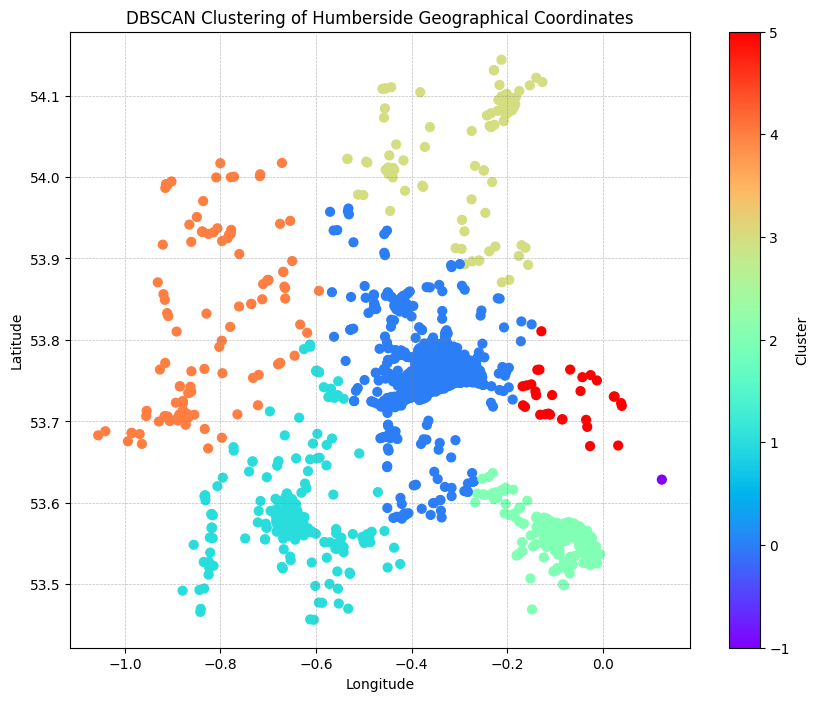

In [105]:
# Scatter plot of Humberside geographical coordinates with clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(humberside_geo_cord['longitude'], humberside_geo_cord['latitude'], c=labels, s=40, cmap='rainbow')
plt.colorbar(scatter, label='Cluster')
plt.title('DBSCAN Clustering of Humberside Geographical Coordinates')

# Add a faint grid for longitude and latitude
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()



### KMediods Clustering

# NO. 6

Using outlier detection methods, identify unusual entries in your data set. Should you keep these entries in your data?

### Outlier Detection methods

#### Multiple of Interquartile Range (IQR) method

In [106]:
#Define function to set the upper and lower bound of the interquartile range
def calculate_outlier_bounds(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q3 -1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound


In [107]:
# Calculate bounds for age_of_driver and age_of_vehicle_df
driver_lower, driver_upper = calculate_outlier_bounds(vehicle_df['age_of_driver'])
driver_lower, driver_upper

(8.5, 89.5)

In [108]:
vehicle_df_lower, vehicle_df_upper = calculate_outlier_bounds(vehicle_df['age_of_vehicle'])
vehicle_df_lower, vehicle_df_upper

(-7.0, 29.0)

In [109]:
casualty_df_lower, casualty_df_upper = calculate_outlier_bounds(casualty_df['age_of_casualty'])
casualty_df_lower, casualty_df_upper

(9.5, 90.5)

In [110]:
# Identify outliers for age_of_driver and age_of_vehicle_df
driver_outliers = vehicle_df[(vehicle_df['age_of_driver'] < driver_lower) | (vehicle_df['age_of_driver'] > driver_upper)]
vehicle_df_outliers = vehicle_df[(vehicle_df['age_of_vehicle'] < vehicle_df_lower) | (vehicle_df['age_of_vehicle'] > vehicle_df_upper)]
casualty_df_outliers = casualty_df[(casualty_df['age_of_casualty'] < casualty_df_lower) | (casualty_df['age_of_casualty'] > casualty_df_upper)]

# Review the detected outliers
print("Age of Driver Outliers:")
driver_outliers

Age of Driver Outliers:


,vehicle_index,accident_index,accident_year,accident_reference,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,driver_home_area_type
2,681718,2020010228005,2020,010228005,1,9,0,18,-1,-1,...,6,3,-1,-1,-1,-1,-1,-1,-1,-1
11,681727,2020010228018,2020,010228018,2,9,0,2,0,0,...,6,3,-1,-1,1984,1,1,AUDI Q5,-1,-1
14,681730,2020010228022,2020,010228022,1,9,0,18,7,3,...,6,1,-1,-1,-1,-1,-1,-1,-1,-1
19,681735,2020010228031,2020,010228031,2,9,9,99,9,9,...,6,3,-1,-1,1229,1,8,VAUXHALL CORSA,-1,-1
21,681737,2020010228032,2020,010228032,2,9,0,2,0,0,...,6,3,-1,-1,1984,1,9,VOLKSWAGEN GOLF,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167258,848974,2020991010956,2020,991010956,2,19,0,2,0,0,...,6,3,-1,-1,-1,-1,-1,-1,-1,-1
167302,849018,2020991012311,2020,991012311,2,19,0,2,0,0,...,6,3,-1,-1,2402,2,12,FORD TRANSIT,-1,-1
167340,849056,2020991016099,2020,991016099,2,9,0,2,0,0,...,6,3,-1,-1,-1,-1,-1,-1,-1,-1
167341,849057,2020991016099,2020,991016099,3,9,0,2,0,0,...,6,3,-1,-1,-1,-1,-1,-1,-1,-1


In [111]:
print("Age of Vehicle Outliers:")
vehicle_df_outliers

Age of Vehicle Outliers:


,vehicle_index,accident_index,accident_year,accident_reference,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,driver_home_area_type
847,682563,2020010229701,2020,010229701,1,9,0,99,9,9,...,6,1,45,7,1108,1,32,-1,2,1
1822,683538,2020010231465,2020,010231465,2,90,0,18,7,3,...,6,1,-1,-1,1971,1,32,FIAT DUCATO,5,1
3450,685166,2020010234271,2020,010234271,2,9,0,5,5,1,...,6,1,51,8,2299,1,30,-1,4,1
3884,685600,2020010234969,2020,010234969,1,4,0,18,1,5,...,6,1,25,5,400,1,30,HONDA MODEL MISSING,8,1
5090,686806,2020010237020,2020,010237020,1,5,0,18,4,8,...,2,1,23,5,500,1,31,-1,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165468,847184,2020990984616,2020,990984616,1,9,0,16,6,2,...,5,1,74,10,3781,1,56,-1,9,3
165498,847214,2020990984765,2020,990984765,1,3,0,4,4,8,...,6,1,27,6,125,1,37,-1,-1,2
166020,847736,2020990992686,2020,990992686,2,17,0,10,1,5,...,1,1,57,9,236,2,33,MASSEY FERGUSON MODEL MISSING,5,3
166180,847896,2020990994835,2020,990994835,1,9,0,2,0,0,...,5,1,23,5,3000,1,30,-1,10,1


In [112]:
print("Age of Casualty Outliers:")
casualty_df_outliers

Age of Casualty Outliers:


,casualty_index,accident_index,accident_year,accident_reference,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile
1,484749,2020010220496,2020,010220496,1,1,3,2,2,1,3,1,1,0,0,0,0,1,2
2,484750,2020010220496,2020,010220496,1,2,3,2,4,1,3,1,1,0,0,0,0,1,2
12,484760,2020010228022,2020,010228022,1,1,1,1,-1,-1,3,0,0,0,0,0,9,-1,-1
18,484766,2020010228031,2020,010228031,1,2,2,-1,-1,-1,3,0,0,1,0,0,9,1,1
29,484777,2020010228087,2020,010228087,1,2,2,1,7,2,2,0,0,2,0,0,9,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115402,600150,2020991009766,2020,991009766,2,2,2,1,7,2,3,0,0,2,0,0,9,3,8
115424,600172,2020991010047,2020,991010047,1,1,3,2,4,1,3,5,3,0,0,0,0,-1,-1
115495,600243,2020991010996,2020,991010996,2,6,2,2,4,1,3,0,0,2,0,0,9,3,7
115543,600291,2020991012929,2020,991012929,2,5,2,1,9,2,2,0,0,2,0,0,9,1,2


In [113]:
# Extract the outliers from the casualty_df_outliers DataFrame
outlier_indices = casualty_df_outliers.index
outlier_age_of_casualty = casualty_df.loc[outlier_indices, 'age_of_casualty']

# Apply KNN imputation on the outlier_age_of_casualty column
knn_imputer = KNNImputer(n_neighbors=5)
imputed_age_of_casualty = knn_imputer.fit_transform(outlier_age_of_casualty.values.reshape(-1, 1))
cleaned_age_of_casualty = pd.Series(imputed_age_of_casualty.flatten(), index=outlier_indices)

In [114]:
def plot_outlier_comparison(original_data, outliers_data, cleaned_data, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    sns.histplot(data=original_data, bins=20, color='blue', label='Original Data', ax=axes[0])
    sns.histplot(data=outliers_data,bins=20, color='red', label='Outliers', ax=axes[1])

    sns.histplot(data=cleaned_data, bins=20, color='green', label='Cleaned Data', ax=axes[2])

    plt.suptitle(title)
    axes[0].set_title('Original Data')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Frequency')

    axes[1].set_title('Detected Outliers')
    axes[1].set_xlabel('Age')
    axes[1].set_ylabel('Frequency')

    axes[2].set_title('Cleaned Data')
    axes[2].set_xlabel('Age')
    axes[2].set_ylabel('Frequency')

    axes[0].legend()
    axes[1].legend()
    axes[2].legend()

    plt.tight_layout()
    plt.show()

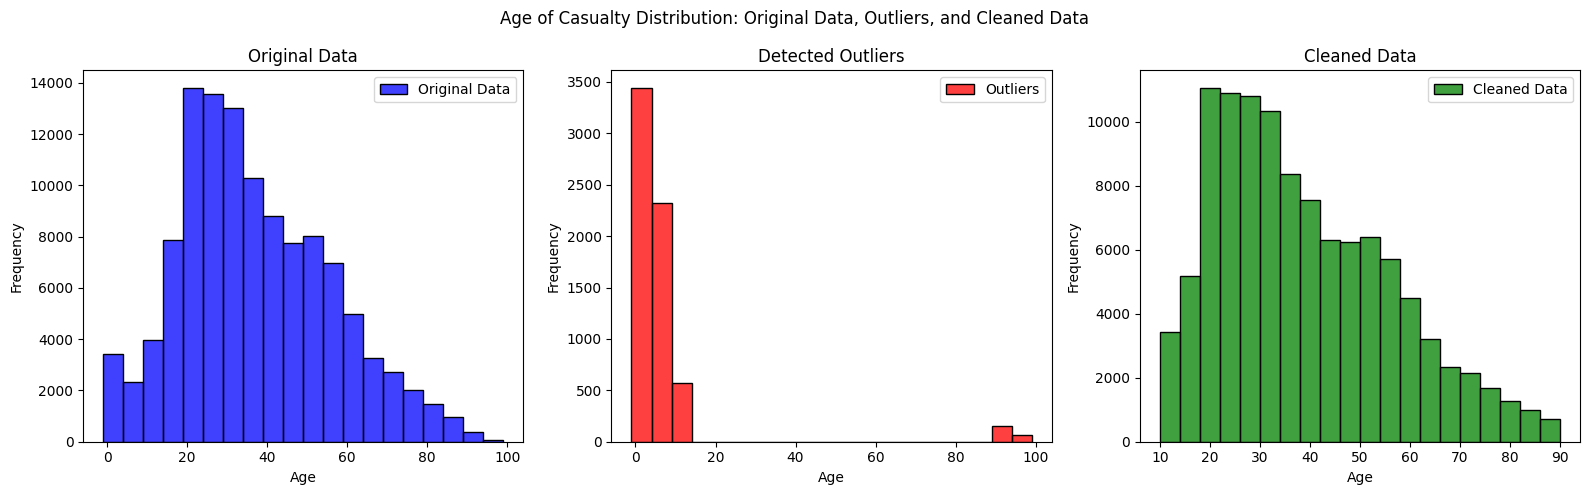

In [115]:
# Apply the function to age_of_casualty outliers
plot_outlier_comparison(casualty_df['age_of_casualty'], casualty_df_outliers['age_of_casualty'], casualty_df['age_of_casualty'].drop(casualty_df_outliers.index), "Age of Casualty Distribution: Original Data, Outliers, and Cleaned Data")


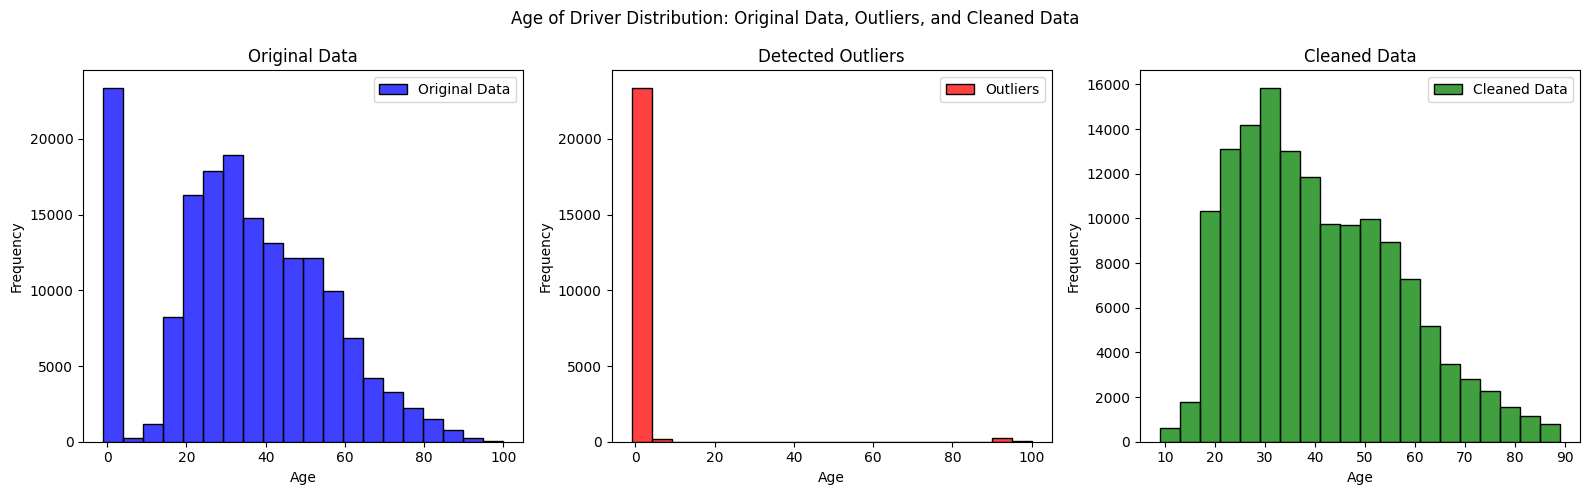

In [116]:
# Apply the function to age_of_driver outliers
plot_outlier_comparison(vehicle_df['age_of_driver'], driver_outliers['age_of_driver'], vehicle_df['age_of_driver'].drop(driver_outliers.index), "Age of Driver Distribution: Original Data, Outliers, and Cleaned Data")


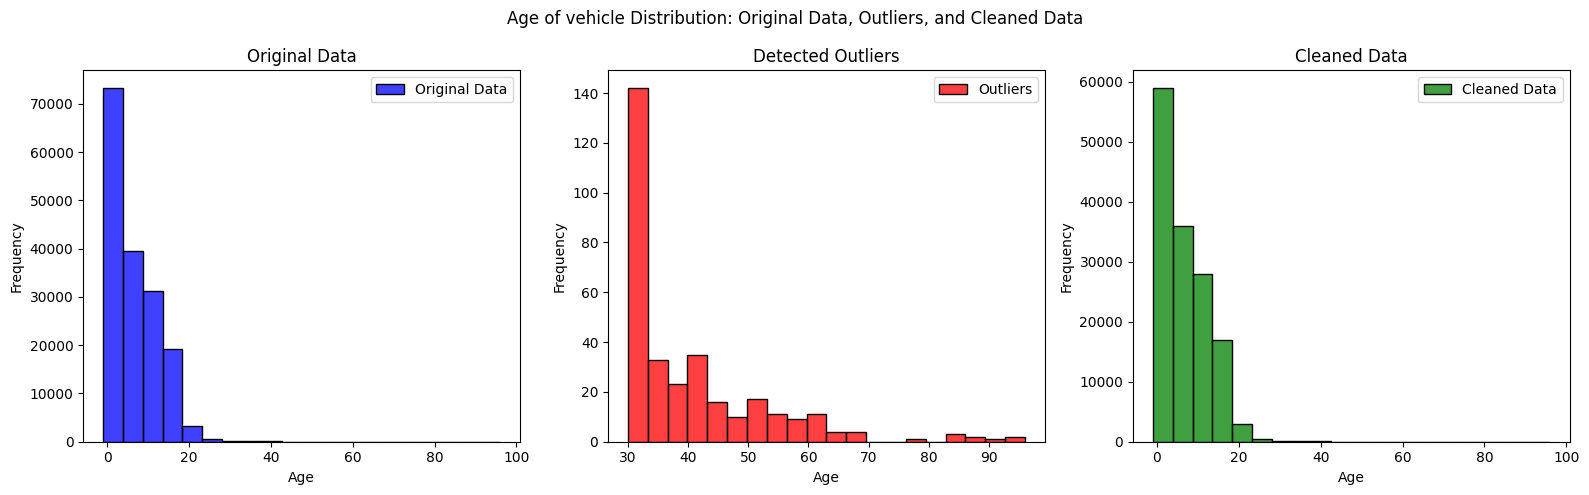

In [117]:
# Apply the function to age_of_driver outliers
plot_outlier_comparison(vehicle_df['age_of_vehicle'], vehicle_df_outliers['age_of_vehicle'], vehicle_df['age_of_vehicle'].drop(driver_outliers.index), "Age of vehicle Distribution: Original Data, Outliers, and Cleaned Data")


Look at the values outside of this range. These are the detected outliers. Do you think they are real outliers? Should you keep them in the data? Do any of the other columns help you in this decision? Whatever you do – document it.
What are the limitations of applying this method to the data?

#### Boxplot

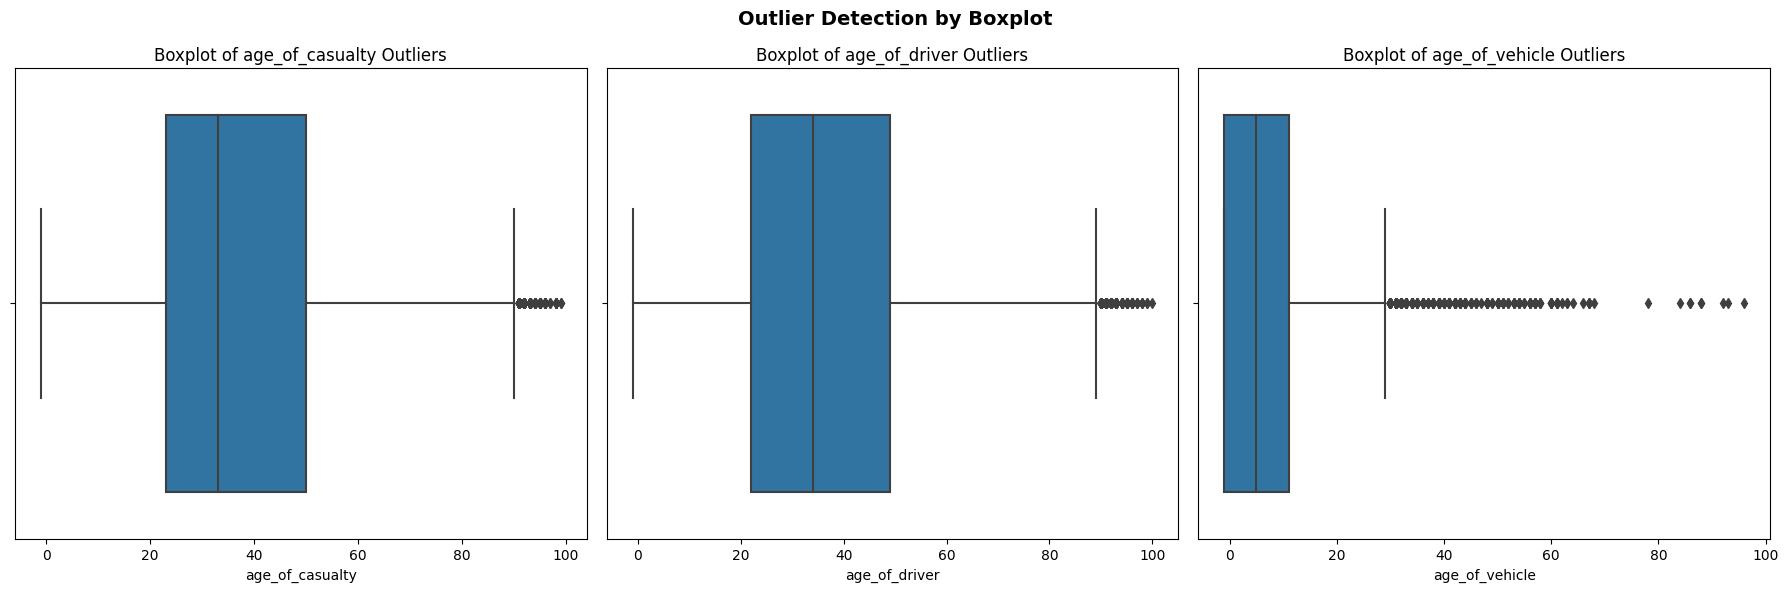

In [118]:
def create_boxplot(data, column, ax):
    sns.boxplot(data=data, x=column, ax=ax)
    ax.set_title(f"Boxplot of {column} Outliers")

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Create boxplot for age_of_casualty
create_boxplot(casualty_df, "age_of_casualty", axes[0])

# Create boxplot for age_of_driver
create_boxplot(vehicle_df, "age_of_driver", axes[1])

# Create boxplot for age_of_vehicle
create_boxplot(vehicle_df, "age_of_vehicle", axes[2])

#Add the super title for the 3 plots
plt.suptitle("Outlier Detection by Boxplot", fontsize = 14, fontweight='bold')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


#### Isolation Forest

In [119]:
def isolation_forest_outliers(df):
    # Select only numerical columns for imputation
    numerical_columns = df.select_dtypes(include=[float, int]).columns

    # Initialize the KNNImputer
    knn_imputer = KNNImputer(n_neighbors=5)

    # Apply KNN imputation to the numerical columns for longitude and latitude with NaN values
    filled_numerical_data = knn_imputer.fit_transform(df[numerical_columns])

    # Create a DataFrame with the filled data
    filled_numerical_df = pd.DataFrame(filled_numerical_data, columns=numerical_columns)

    # Replace the original numerical columns with the filled data
    df[numerical_columns] = filled_numerical_df

    # Create a new data frame with only numerical columns
    numerical_df = df.select_dtypes(include=[float, int])

    # Create an Isolation Forest object
    isolation_forest = IsolationForest(contamination=0.05, random_state=42)

    # Fit the Isolation Forest to the numerical data
    isolation_forest.fit(numerical_df)

    # Predict outliers (-1 for outliers, 1 for inliers)
    outlier_flags = isolation_forest.predict(numerical_df)

    num_outliers = (outlier_flags == -1).sum()

    df['outlier'] = num_outliers

    print(f"Number of outliers: {num_outliers}")

# Apply the function to accident_df
isolation_forest_outliers(accident_df)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Number of outliers: 4560


In [120]:
# Apply the function to casualty_df
isolation_forest_outliers(casualty_df)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Number of outliers: 5780


In [121]:
# Apply the function to vehicle_df
isolation_forest_outliers(vehicle_df)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Number of outliers: 8350


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


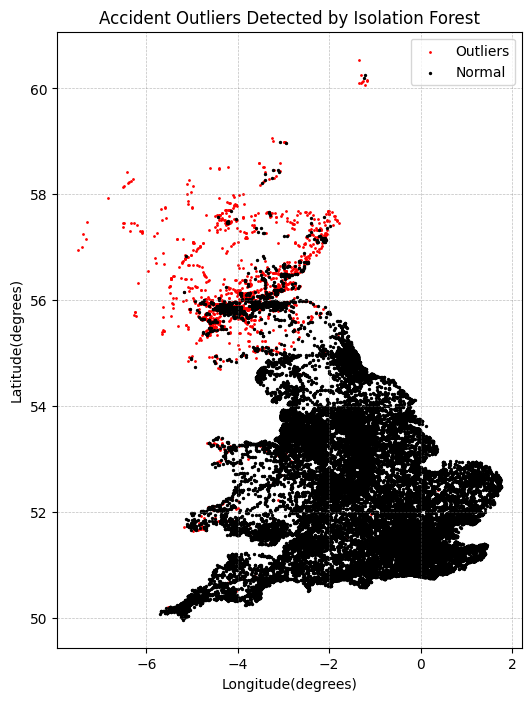

In [122]:
# Select numerical columns for Isolation Forest
numerical_columns = accident_df.select_dtypes(include=[float, int]).columns

# Create an Isolation Forest object
isolation_forest = IsolationForest(contamination=0.05, random_state=42)

# Fit the Isolation Forest to the numerical data
outlier_flags = isolation_forest.fit_predict(accident_df[numerical_columns])

# Add the predicted outlier flags as a new column to accident_df
accident_df['outlier'] = outlier_flags

# Create scatter plots for outliers and normal data
plt.figure(figsize=(6, 8))

# Outliers (outlier == -1)
plt.scatter(accident_df[accident_df['outlier'] == -1]['longitude'], accident_df[accident_df['outlier'] == -1]['latitude'], c='red', label='Outliers', s =1)

# Normal data (outlier == 1)
plt.scatter(accident_df[accident_df['outlier'] == 1]['longitude'], accident_df[accident_df['outlier'] == 1]['latitude'], c='black', label='Normal',s = 2)

# Add a faint grid
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.xlabel('Longitude(degrees)')
plt.ylabel('Latitude(degrees)')
plt.title('Accident Outliers Detected by Isolation Forest')
plt.legend()
plt.show()

In [123]:
#Detect number of outliers per contamination value
def isolation_forest_outliers(df, contamination=0.05):
    # Select only numerical columns for imputation
    numerical_columns = df.select_dtypes(include=[float, int]).columns

    # Initialize the KNNImputer
    knn_imputer = KNNImputer(n_neighbors=5)

    # Apply KNN imputation to the numerical columns for longitude and latitude with NaN values
    filled_numerical_data = knn_imputer.fit_transform(df[numerical_columns])

    # Create a DataFrame with the filled data
    filled_numerical_df = pd.DataFrame(filled_numerical_data, columns=numerical_columns)

    # Replace the original numerical columns with the filled data
    df[numerical_columns] = filled_numerical_df

    # Create a new data frame with only numerical columns
    numerical_df = df.select_dtypes(include=[float, int])

    # Create an Isolation Forest object
    isolation_forest = IsolationForest(contamination=contamination, random_state=42)

    # Fit the Isolation Forest to the numerical data
    isolation_forest.fit(numerical_df)

    # Predict outliers (-1 for outliers, 1 for inliers)
    outlier_flags = isolation_forest.predict(numerical_df)

    num_outliers = (outlier_flags == -1).sum()

    df['outlier'] = outlier_flags  # Store the outlier flags in the DataFrame

    print(f"Number of outliers for contamination {contamination}: {num_outliers}")

    return num_outliers

contamination_values = [0.01, 0.02, 0.05, 0.07, 0.1]
outliers_data = []

for contamination in contamination_values:
    num_outliers = isolation_forest_outliers(accident_df, contamination)
    outliers_data.append({'Contamination value': contamination, 'Number of Outliers': num_outliers})

# Create a DataFrame from the list of dictionaries
outliers_df = pd.DataFrame(outliers_data)

outliers_df

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Number of outliers for contamination 0.01: 912


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Number of outliers for contamination 0.02: 1824


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


...

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Number of outliers for contamination 0.07: 6384


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Number of outliers for contamination 0.1: 9120


,Contamination value,Number of Outliers
0,0.01,912
1,0.02,1824
2,0.05,4560
3,0.07,6384
4,0.10,9120


#### Local Outlier Factor Outlier Detection

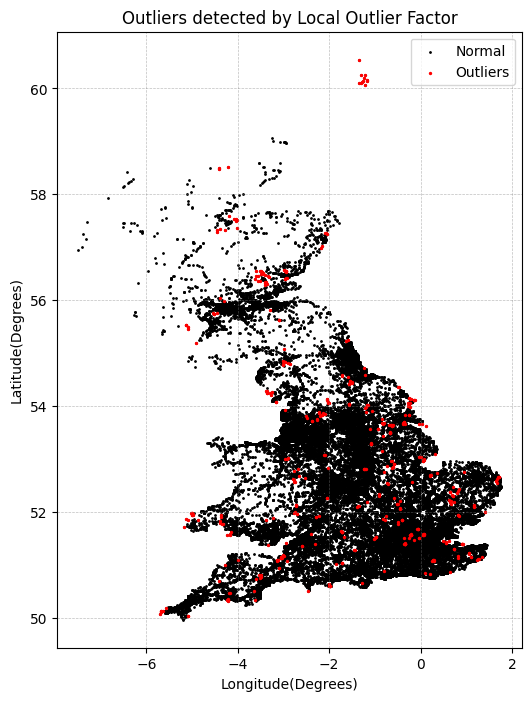

In [124]:
#Extract location data from accident table
X = accident_df[['longitude', 'latitude']]

#Initiate LocalOutlierFactor model for outlier detection with contamination of 0.005, meaning that 0.5% of the data could be outliers
lof_model = LocalOutlierFactor(contamination=0.005)

# Fit and predict outliers
outlier_labels = lof_model.fit_predict(X)

# Select the outliers
outliers = X[outlier_labels == -1]

# Plot the data
plt.figure(figsize=(6, 8))
plt.scatter(X['longitude'], X['latitude'], c='black', label='Normal', s =1)
plt.scatter(outliers['longitude'], outliers['latitude'], c='red', label='Outliers', s = 2)

# Add a faint grid
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.xlabel('Longitude(Degrees)')
plt.ylabel('Latitude(Degrees)')
plt.title('Outliers detected by Local Outlier Factor')
plt.legend()

plt.show()

##### Mahalanobi's Distance Anomaly Detection

In [125]:
#Soure : Three Multivariate Outlier methods. Week 8. Big Data and Data Mining code Document
import scipy as sp
from scipy.stats import chi2
from sklearn.covariance import MinCovDet

def mahalanobis_method(df):
    x_minus_mu = df - np.mean(df)
    cov = np.cov(df.values.T)
    inv_covmat = sp.linalg.inv(cov)
    left_term = np.dot(x_minus_mu, inv_covmat)
    mahal = np.dot(left_term, x_minus_mu.T)
    md = np.sqrt(mahal.diagonal())

    outlier = []
    C = np.sqrt(chi2.ppf((1-0.05), df=df.shape[1]))
    for index, value in enumerate(md):
        if value > C:
            outlier.append(index)
        else:
            continue
    return outlier, md

In [126]:
# Assign a subset of the geographic locations due to computationally expensive mahalanobis
subset_size = 500  # Specify the number of rows in the subset

# Get a random subset of geo_cord
random_subset = geo_cord.sample(n=subset_size, random_state=42)  # Set random_state for reproducibility

# Now you can use the random_subset DataFrame for Mahalanobis distance calculations


In [127]:
out_mlobis, md = mahalanobis_method(df=random_subset)
out_mlobis, md

([22,
  35,
  36,
  70,
  115,
  134,
  151,
  158,
  160,
  184,
  201,
  263,
  282,
  286,
  298,
  305,
  310,
  314,
  317,
  323,
  326,
  374,
  376,
  391,
  399,
  419,
  433,
  477],
 array([1.56605484, 1.34083766, 1.48883316, 1.62793067, 2.04377289,
        1.5932518 , 1.65373964, 1.30950853, 2.37334163, 1.619253  ,
        1.29347003, 1.33488895, 0.70404405, 1.70861617, 1.97234795,
        1.33423242, 1.35020027, 1.9855752 , 1.62232702, 1.52810721,
        2.2048966 , 1.93086117, 3.05078898, 1.52549767, 1.44115585,
        1.83322343, 1.51486096, 1.44042947, 2.62687722, 1.98805623,
        1.32297186, 1.44287608, 1.65089405, 1.51257879, 1.92762792,
        3.24692841, 2.85484453, 1.03277403, 1.33869083, 1.03125088,
        1.72328208, 1.24776998, 0.92434809, 1.22610523, 1.35334338,
        1.64055142, 2.72093094, 1.35472189, 1.99438576, 2.62862063,
        1.6975031 , 1.96713859, 1.34841348, 1.77882623, 1.27065111,
        1.79647736, 1.65823525, 1.57944262, 1.89219619, 1.2

In [128]:
column_names = ["longitude", "latitude"]
anomalies = pd.DataFrame(columns = column_names)

for i in out_mlobis:
    anomalies=outliers.append(random_subset.iloc[i])

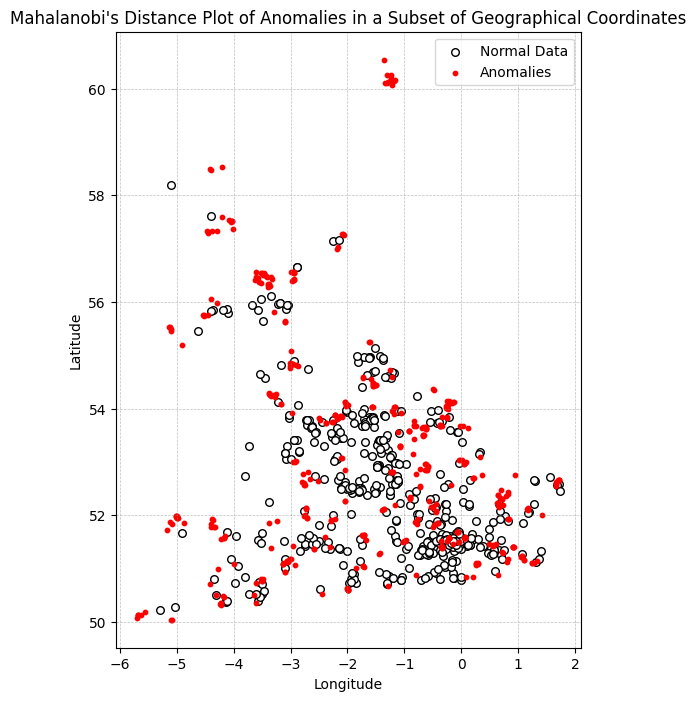

In [129]:
plt.figure(figsize=(6, 8))
plt.scatter(random_subset['longitude'], random_subset['latitude'], c='white', s=30, edgecolor='k', label='Normal Data')
plt.scatter(anomalies['longitude'], anomalies['latitude'], c='red', label='Anomalies', s = 10)

plt.title('Mahalanobi\'s Distance Plot of Anomalies in a Subset of Geographical Coordinates')
# Add a faint grid
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

#### Grubb's Test

Null Hypothesis = There are no outliers in the dataset

Alternative hypothesis = There is One outlier in the dataset

In [130]:
def apply_grubbs_test(data):
    # Compute Grubbs' test statistic for each data point

    # Calculate the critical G value
    critical_G_value = critical_grubbs(len(data), 0.05) #0.05 significance level

    # Find the index of the maximum G value using the np.argmax function
    max_G_index = np.argmax(critical_G_value)

    return max_G_index, critical_G

For age_of_vehicle:

Grubbs' test value: 17.897835992986483
Critical G value: 5.124052908584172
For age_of_driver:

Grubbs' test value: 3.9701685021989843
Critical G value: 5.124052908584172
In the case of age_of_vehicle, the Grubbs' test value is higher than the critical G value, indicating that there might be outliers in the data. On the other hand, for age_of_driver, the Grubbs' test value is lower than the critical G value, suggesting that there are no outliers based on the Grubbs' test.







In [131]:
def grubbs_fxn(data):
    data_mean = np.mean(data)
    absval = abs(data - data_mean)
    maxval = max(absval)
    std_dev = np.std(data)

    G = maxval / std_dev
    return G

def critical_grubbs(n, alpha):
    t_dist = stats.t.ppf(1 - alpha / (2 * n), n - 2)
    top = (n - 1) * np.sqrt(np.square(t_dist))
    bottom = np.sqrt(n) * np.sqrt(n - 2 + np.square(t_dist))
    critical_G = top / bottom
    return critical_G

# Calculate Grubbs' test values, critical G values, and max critical G values for specified columns

# For age_of_vehicle column in vehicle_df
grubbs_age_of_vehicle = grubbs_fxn(vehicle_df['age_of_vehicle'])
critical_G_value_age_of_vehicle = critical_grubbs(len(vehicle_df['age_of_vehicle']), 0.05)
max_critical_G_age_of_vehicle = np.max(critical_G_value_age_of_vehicle)

# For age_of_driver column in vehicle_df
grubbs_age_of_driver = grubbs_fxn(vehicle_df['age_of_driver'])
critical_G_value_age_of_driver = critical_grubbs(len(vehicle_df['age_of_driver']), 0.05)
max_critical_G_age_of_driver = np.max(critical_G_value_age_of_driver)

# For number_of_vehicles column in accident_df
grubbs_number_of_vehicles = grubbs_fxn(accident_df['number_of_vehicles'])
critical_G_value_number_of_vehicles = critical_grubbs(len(accident_df['number_of_vehicles']), 0.05)
max_critical_G_number_of_vehicles = np.max(critical_G_value_number_of_vehicles)

# For number_of_casualties column in accident_df
grubbs_number_of_casualties = grubbs_fxn(accident_df['number_of_casualties'])
critical_G_value_number_of_casualties = critical_grubbs(len(accident_df['number_of_casualties']), 0.05)
max_critical_G_number_of_casualties = np.max(critical_G_value_number_of_casualties)

# For age_of_casualty column in casualty_df
grubbs_age_of_casualty = grubbs_fxn(casualty_df['age_of_casualty'])
critical_G_value_age_of_casualty = critical_grubbs(len(casualty_df['age_of_casualty']), 0.05)
max_critical_G_age_of_casualty = np.max(critical_G_value_age_of_casualty)

In [132]:
# Create a dictionary with the results
results_dict = {
    'Column': ['age_of_vehicle', 'age_of_driver', 'number_of_vehicles', 'number_of_casualties', 'age_of_casualty'],
    'Grubbs Test Value': [grubbs_age_of_vehicle, grubbs_age_of_driver, grubbs_number_of_vehicles, grubbs_number_of_casualties, grubbs_age_of_casualty],
    'Critical G Value': [critical_G_value_age_of_vehicle, critical_G_value_age_of_driver, critical_G_value_number_of_vehicles, critical_G_value_number_of_casualties, critical_G_value_age_of_casualty],
    'Max Critical G Value': [max_critical_G_age_of_vehicle, max_critical_G_age_of_driver, max_critical_G_number_of_vehicles, max_critical_G_number_of_casualties, max_critical_G_age_of_casualty]
}

# Create a DataFrame from the dictionary
results_df = pd.DataFrame(results_dict)

# Print the DataFrame
results_df


,Column,Grubbs Test Value,Critical G Value,Max Critical G Value
0,age_of_vehicle,14.242053,5.124053,5.124053
1,age_of_driver,3.148959,5.124053,5.124053
2,number_of_vehicles,16.484938,5.008277,5.008277
3,number_of_casualties,58.304320,5.008277,5.008277
4,age_of_casualty,3.292623,5.053761,5.053761


For age_of_vehicle, the Grubbs' test value is significantly larger than the critical G value, indicating the presence of outliers in this feature.

For age_of_driver, the Grubbs' test value is not significantly larger than the critical G value, suggesting that there might not be outliers in this feature.

For number_of_vehicles and number_of_casualties, the Grubbs' test values are significantly larger than the critical G value, indicating the presence of outliers in these features.

For age_of_casualty, the Grubbs' test value is not significantly larger than the critical G value, suggesting that there might not be outliers in this feature.

### Hampel filter for treating outliers detected by Grubbs Test

In [133]:
#source: Week 8 Big Data Lecture, DAIM University of Hull File = hampel_demo.ipynb
#Source = https://pypi.org/project/hampel/#modal-close

In [134]:
def hampel_filter(data, window_size=3, n_sigmas=3):
    median = data.rolling(window=window_size, center=True).median()
    mad = (data - median).abs().rolling(window=window_size, center=True).median()
    threshold = n_sigmas * 1.4826 * mad
    outliers = (data - median).abs() > threshold
    data[outliers] = median[outliers]  # Replace outliers with the median
    return data

# Apply Hampel filter to columns with identified outliers
vehicle_df['hampel_age_of_vehicle'] = hampel_filter(vehicle_df['age_of_vehicle'])
accident_df['hampel_number_of_vehicles'] = hampel_filter(accident_df['number_of_vehicles'])
accident_df['hampel_number_of_casualties'] = hampel_filter(accident_df['number_of_casualties'])


<ipython-input-134-cd0b28041431>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[outliers] = median[outliers]  # Replace outliers with the median
<ipython-input-134-cd0b28041431>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[outliers] = median[outliers]  # Replace outliers with the median
<ipython-input-134-cd0b28041431>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[outliers] = median[outliers]  # Replace outliers

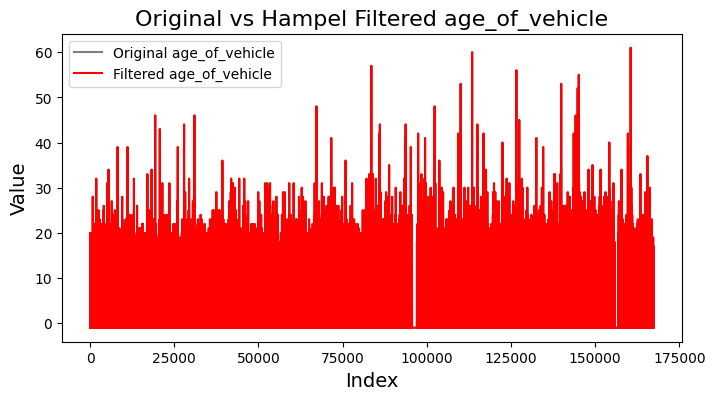

In [135]:
#Visualise the inputs and cleaniing done by Hampel filter

# Set the figure size
plt.figure(figsize=(8, 4))

# Original age_of_vehicle values
plt.plot(vehicle_df['age_of_vehicle'], label='Original age_of_vehicle', color='black', alpha=0.5)

# Filtered age_of_vehicle values
plt.plot(vehicle_df['hampel_age_of_vehicle'], label='Filtered age_of_vehicle', color = "r")

# Add title and labels
plt.title('Original vs Hampel Filtered age_of_vehicle', fontsize=16)
plt.xlabel('Index', fontsize=14)
plt.ylabel('Value', fontsize=14)
plt.legend()

# Display the plot
plt.show()


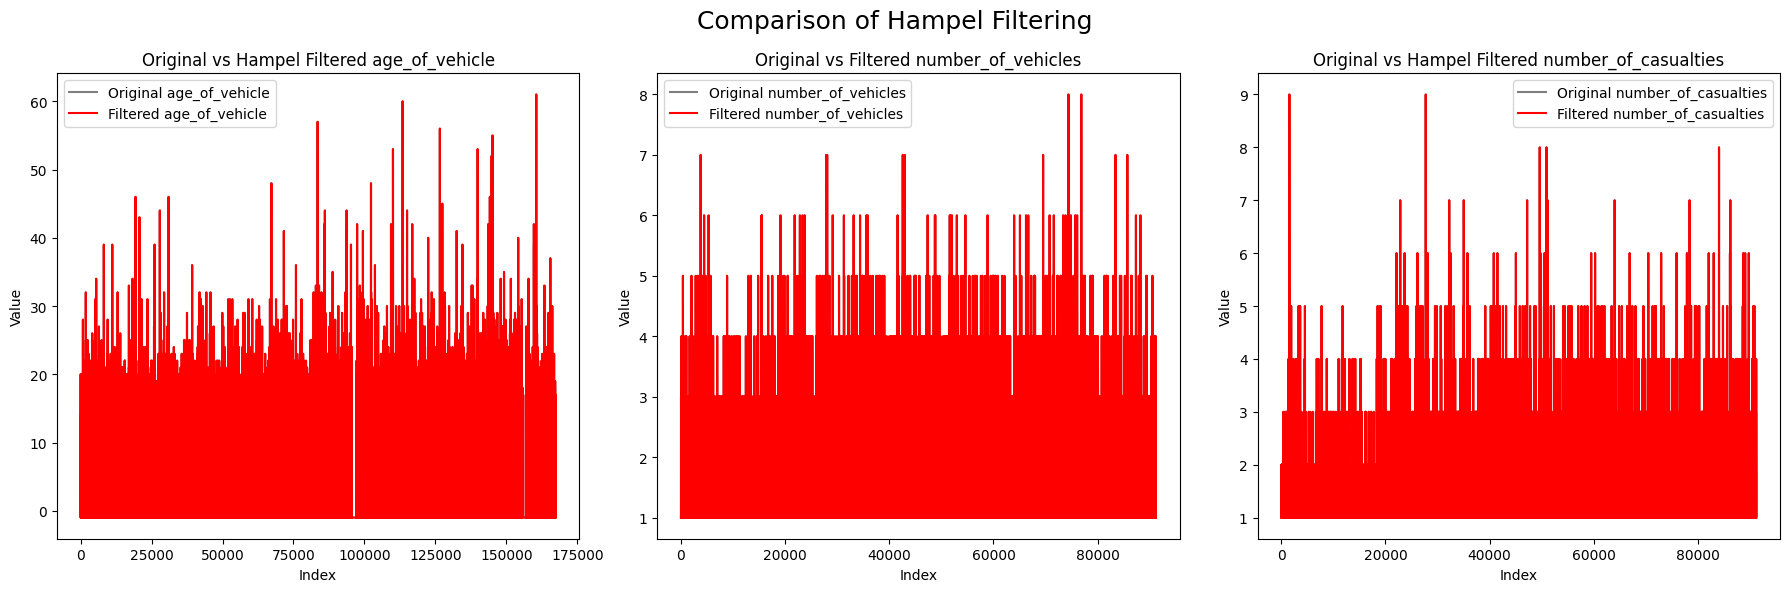

In [136]:
# Set the figure size
plt.figure(figsize=(18, 6))

# Create subplots
plt.subplot(1, 3, 1)
plt.plot(vehicle_df['age_of_vehicle'], label='Original age_of_vehicle', color='black', alpha=0.5)
plt.plot(vehicle_df['hampel_age_of_vehicle'], label='Filtered age_of_vehicle', color='red')
plt.title('Original vs Hampel Filtered age_of_vehicle')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(accident_df['number_of_vehicles'], label='Original number_of_vehicles', color='black', alpha=0.5)
plt.plot(accident_df['hampel_number_of_vehicles'], label='Filtered number_of_vehicles', color='red')
plt.title('Original vs Filtered number_of_vehicles')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(accident_df['number_of_casualties'], label='Original number_of_casualties', color='black', alpha=0.5)
plt.plot(accident_df['hampel_number_of_casualties'], label='Filtered number_of_casualties', color='red')
plt.title('Original vs Hampel Filtered number_of_casualties')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

# Add a common title for the entire plot
plt.suptitle('Comparison of Hampel Filtering', fontsize=18)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()


Compute Median and Median Absolute Deviation (MAD): The first step of the Hampel filter involves calculating the rolling median of the data. The window size for this rolling median can be adjusted based on the data's characteristics. Additionally, the Median Absolute Deviation (MAD) is calculated, which measures the dispersion of the data from the median.

Calculate Threshold for Outlier Detection: The threshold for identifying outliers is determined by multiplying the MAD by a constant factor (usually denoted by n_sigmas, often set to 3). This threshold value represents a certain number of standard deviations away from the median.

Identify Outliers: Data points that have an absolute difference from the median greater than the threshold are identified as outliers. These are the data points that deviate significantly from the central tendency of the data.

Replace Outliers with Median: The identified outliers are then replaced with the corresponding median value. This replacement helps to mitigate the impact of outliers on subsequent analyses and statistics that are sensitive to extreme values.

Retain Original Data Distribution: One of the advantages of using the Hampel filter is that it replaces outliers with a value (median) that is consistent with the overall distribution of the data. Unlike methods that remove outliers entirely, the Hampel filter retains the data's original distribution while still reducing the impact of outliers.

Repeat for the Entire Dataset: The above steps are repeated for the entire dataset, ensuring that outliers in all relevant columns are handled.

Applying the Hampel filter effectively "smooths" the dataset by replacing extreme values with more representative values (medians) that are less affected by outliers. This can help improve the stability and reliability of subsequent analyses, visualizations, and modeling tasks performed on the cleaned data.







# No. 7

Can you develop a classification model using the provided data that accurately predicts fatal injuries sustained in road traffic accidents, with the aim of informing and improving road safety measures?

## Modelling

In [137]:
#Feature Selection: Select entries of the accidnet dataframe that are classified as fatal
y= accident_df['accident_severity']==1

#Check if the data is balanced. Data is not balanced
y.value_counts()

False    89808
True      1391
Name: accident_severity, dtype: int64

In [138]:
#Balalnce the target feature
accident_df_balanced, y_balanced = RandomUnderSampler().fit_resample(accident_df, y)

#check to see if the balncing has been completed
y_balanced.value_counts()


False    1391
True     1391
Name: accident_severity, dtype: int64

In [139]:
#accident_df_balanced= accident_df_balanced.drop(["accident_reference",'accident_index'	,'did_police_officer_attend_scene_of_accident', "lsoa_of_accident_location"], axis =1)
accident_df_balanced = accident_df_balanced.select_dtypes(exclude='object')

In [140]:
accident_df_balanced

,accident_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,number_of_casualties,day_of_week,...,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,hour_time,outlier,hampel_number_of_vehicles,hampel_number_of_casualties
0,2020.0,517688.0,282683.0,-0.270473,52.429488,35.0,3.0,3.0,1.0,3.0,...,1.0,0.0,0.0,2.0,1.0,1.0,16.950000,1,3.0,1.0
1,2020.0,524585.0,178400.0,-0.206872,51.490831,1.0,3.0,2.0,1.0,3.0,...,1.0,0.0,0.0,1.0,3.0,2.0,13.500000,1,2.0,1.0
2,2020.0,407811.0,275133.0,-1.886682,52.374199,22.0,3.0,1.0,1.0,5.0,...,2.0,0.0,0.0,1.0,1.0,2.0,7.683333,1,1.0,1.0
3,2020.0,534234.0,181604.0,-0.066751,51.517417,1.0,3.0,2.0,1.0,4.0,...,1.0,0.0,0.0,1.0,3.0,2.0,18.750000,1,2.0,1.0
4,2020.0,311896.0,174887.0,-3.269722,51.466070,62.0,3.0,2.0,1.0,3.0,...,1.0,0.0,0.0,1.0,1.0,-1.0,16.833333,1,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,2020.0,254367.0,661245.0,-4.326142,55.822415,99.0,1.0,2.0,1.0,2.0,...,2.0,0.0,0.0,1.0,1.0,-1.0,17.650000,-1,2.0,1.0
2778,2020.0,270790.0,659812.0,-4.063523,55.814225,99.0,1.0,2.0,1.0,2.0,...,2.0,0.0,0.0,1.0,1.0,-1.0,18.566667,-1,2.0,1.0
2779,2020.0,113410.0,903322.0,-6.842655,57.926736,99.0,1.0,1.0,1.0,5.0,...,1.0,0.0,0.0,2.0,1.0,-1.0,9.066667,-1,1.0,1.0
2780,2020.0,381609.0,654146.0,-2.294786,55.780278,99.0,1.0,2.0,1.0,6.0,...,2.0,0.0,0.0,2.0,1.0,-1.0,10.633333,-1,2.0,1.0


In [141]:
#select best features for the classification using selectkBest and initialise k to 10
skb = SelectKBest(f_classif, k=10)

#fit skb to the data
skb.fit(accident_df_balanced, y_balanced)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


SelectKBest()

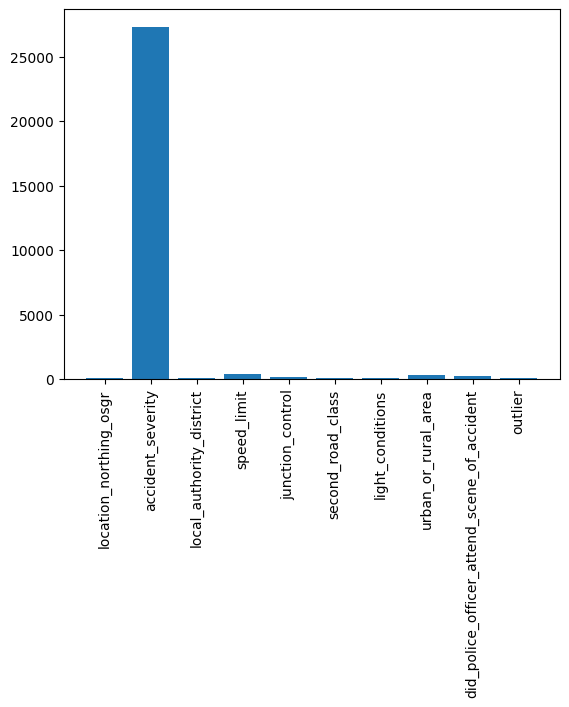

In [142]:
mk = skb.get_support()
feat =skb.feature_names_in_[mk]
scores = skb.scores_[mk]


#View the relevant columns through a plot
plt.bar(feat, scores)
plt.xticks(rotation ='vertical');

In [143]:
feat

array(['location_northing_osgr', 'accident_severity',
       'local_authority_district', 'speed_limit', 'junction_control',
       'second_road_class', 'light_conditions', 'urban_or_rural_area',
       'did_police_officer_attend_scene_of_accident', 'outlier'],
      dtype=object)

In [144]:
#Assign feature names to a variable and add to the dataframe
add_feature = [
    'local_authority_district', "first_road_class", 'speed_limit', 'junction_control',
    'second_road_class','pedestrian_crossing_human_control', 'light_conditions','urban_or_rural_area'
    ]

In [145]:
 accident_df_balanced =  accident_df_balanced[add_feature]


In [146]:
#drop values not needed and select the features needed
X = accident_df_balanced
y = y_balanced

In [147]:
#Split the data into training and testing data
#Not normalising because we are not using distance based metrics

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =  0.2, random_state = 42)

### Random Forest Classifer

In [148]:
rf = RandomForestClassifier()
rf

RandomForestClassifier()

In [149]:
#Fit the data
rf.fit(X_train, y_train)

#Make prediction
rf_pred = rf.predict(X_test)

In [152]:
#Source: Week 10 Lab Session
#Define function to be called for evaluation metrics
def evaluate_classification_model(model, predictors, target, threshold=0.5):

    # Model prediction
    pred_proba = model.predict_proba(predictors)[:, 1]

    # Class predictions
    pred_class = np.round(pred_proba > threshold)

    # Compute evaluation metrics: accuracy, recall, precision, and F1-score
    acc = accuracy_score(target, pred_class)
    recall = recall_score(target, pred_class, average="weighted")
    precision = precision_score(target, pred_class, average="weighted")
    f1 = f1_score(target, pred_class, average="weighted")

    # Create a DataFrame of the metrics to show scores
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1-score": f1
        },
        index=[0])

    # Plot the confusion matrix
    conf = confusion_matrix(target, pred_class)

    #make a heatmap of the confusion matrix
    sns.heatmap(conf, annot=True, fmt="g")
    plt.title("Confusion Matrix of the Random Forest Model Prediction")
    plt.xticks([0.5, 1.5], labels=["Predicted Non-Fatal", "Predicted Fatal"])
    plt.yticks([0.5, 1.5], labels=["Actual Non-Fatal", "Actual Fatal"])
    plt.figure(figsize=(15, 15))

    plt.show()

    return df_perf


In [157]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

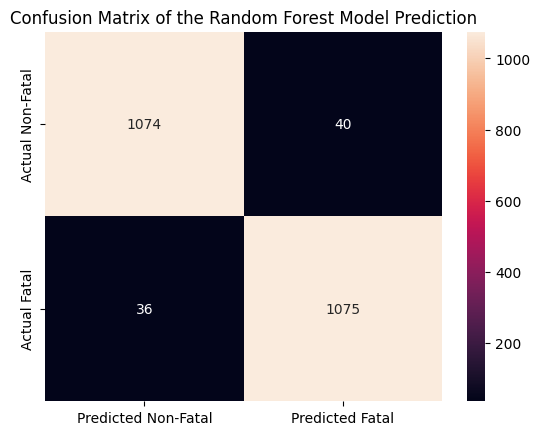

<Figure size 1500x1500 with 0 Axes>

,Accuracy,Recall,Precision,F1-score
0,0.965843,0.965843,0.965849,0.965843


In [158]:
evaluate_classification_model(rf, X_train, y_train)